Adding CPG values to dataset as it wasnt included on RCA tool

In [ ]:


import re
import shutil
import numpy as np
import pandas as pd
from openpyxl import load_workbook
    
# -----------------------------
# Files
# -----------------------------
STATS_FILE  = "heuristic-statistical-descriptors.xlsx"
STATS_SHEET = "All_Data"
TITER_FILE  = "master-data.xlsx"
TITER_SHEET = 0
ID_COL      = "Molecule"

SEQ_FILE    = "patented+mutated-sequences-with-evo-scores.xlsx"
SEQ_SHEET   = "Scored_Sequences"
PAT_SEQ_COL = "Original_DNA"
OPT_SEQ_COL = "Optimized_DNA"

NEW_COLUMNS = ["CpG_OE", "UpA_OE", "CpG_freq", "UpA_freq"]

MAKE_BACKUP = True
BACKUP_FILE = "rare_codon_extract_BACKUP.xlsx"

# -----------------------------
# Helpers
# -----------------------------
def normalize_therapeutic(s):
    return re.sub(r"\s+", " ", str(s).strip())

def normalize_chain_id(s):
    return re.sub(r"\s+", " ", str(s).strip()).title()

def clean_dna(seq):
    if not isinstance(seq, str):
        return ""
    s = "".join(seq.split()).upper().replace("U", "T")
    return "".join(c if c in "ACGT" else "" for c in s)

def base_freqs(seq):
    n = len(seq)
    if n == 0:
        return {b: 0.0 for b in "ACGT"}
    return {b: seq.count(b) / n for b in "ACGT"}

def dinuc_count(seq, di):
    if len(seq) < 2:
        return 0
    return sum(1 for i in range(len(seq) - 1) if seq[i:i+2] == di)

def dinuc_oe(seq, di):
    if len(seq) < 2:
        return None
    n_dinuc = len(seq) - 1
    obs = dinuc_count(seq, di) / n_dinuc
    f = base_freqs(seq)
    expected = f.get(di[0], 0.0) * f.get(di[1], 0.0)
    return obs / expected if expected > 1e-12 else None

def dinuc_freq_per_nt(seq, di):
    if len(seq) < 2:
        return None
    return dinuc_count(seq, di) / len(seq)

# -----------------------------
# 1) Build allowed therapeutic set from codons-data-new
# -----------------------------
print(f"Reading molecules from {TITER_FILE}")
titer = pd.read_excel(TITER_FILE, sheet_name=TITER_SHEET, engine="openpyxl")
titer = titer.dropna(subset=[ID_COL]).copy()
titer[ID_COL] = titer[ID_COL].astype(str).str.strip()

parsed = titer[ID_COL].str.extract(
    r"^(?P<Base>.+?)\s+(?:Mutated|Patent)\s*$",
    flags=re.IGNORECASE,
)
allowed_therapeutics = set(
    parsed["Base"].dropna().apply(normalize_therapeutic).unique()
)
print(f"Allowed therapeutics: {len(allowed_therapeutics)}")

# -----------------------------
# 2) Build CpG/UpA metric lookup from sequence file
# -----------------------------
print(f"\nReading sequences from {SEQ_FILE}")
seq_df = pd.read_excel(SEQ_FILE, sheet_name=SEQ_SHEET, engine="openpyxl")
seq_df = seq_df.dropna(subset=["Therapeutic", "Chain",
                               PAT_SEQ_COL, OPT_SEQ_COL]).copy()

seq_df["Therapeutic_norm"] = seq_df["Therapeutic"].apply(normalize_therapeutic)
seq_df["ChainID_norm"]     = seq_df["Chain"].apply(normalize_chain_id)
seq_df[PAT_SEQ_COL]        = seq_df[PAT_SEQ_COL].apply(clean_dna)
seq_df[OPT_SEQ_COL]        = seq_df[OPT_SEQ_COL].apply(clean_dna)

metrics_lookup = {}
for _, row in seq_df.iterrows():
    ther = row["Therapeutic_norm"]
    cid  = row["ChainID_norm"]
    pat  = row[PAT_SEQ_COL]
    opt  = row[OPT_SEQ_COL]
    metrics_lookup[(ther, cid, "Patent")] = {
        "CpG_OE":   dinuc_oe(pat, "CG"),
        "UpA_OE":   dinuc_oe(pat, "TA"),
        "CpG_freq": dinuc_freq_per_nt(pat, "CG"),
        "UpA_freq": dinuc_freq_per_nt(pat, "TA"),
    }
    metrics_lookup[(ther, cid, "Mutated")] = {
        "CpG_OE":   dinuc_oe(opt, "CG"),
        "UpA_OE":   dinuc_oe(opt, "TA"),
        "CpG_freq": dinuc_freq_per_nt(opt, "CG"),
        "UpA_freq": dinuc_freq_per_nt(opt, "TA"),
    }
print(f"CpG/UpA metrics computed for {len(metrics_lookup)} sequence variants")

# -----------------------------
# 3) Backup
# -----------------------------
if MAKE_BACKUP:
    shutil.copy(STATS_FILE, BACKUP_FILE)
    print(f"\nBackup written: {BACKUP_FILE}")

# -----------------------------
# 4) Open rare_codon_extract.xlsx
# -----------------------------
print(f"\nOpening {STATS_FILE}")
wb = load_workbook(STATS_FILE)
if STATS_SHEET not in wb.sheetnames:
    raise ValueError(f"Sheet '{STATS_SHEET}' not found")
ws = wb[STATS_SHEET]

header = [cell.value for cell in ws[1]]
if "Chain" not in header:
    raise ValueError("Could not find 'Chain' column")
chain_col_idx = header.index("Chain") + 1

# -----------------------------
# 5) Scan rows — decide which to keep
# -----------------------------
chain_pattern = re.compile(
    r"^(?P<Therapeutic>.+?)\s+(?P<ChainID>(?:Heavy|Light)\s*\d+)\s+(?P<Variant>Patent|Mutated)\s*$",
    re.IGNORECASE,
)

rows_to_delete = []
kept_count = 0
unmatched_examples = []
unmatched_therapeutics = set()

for row_idx in range(2, ws.max_row + 1):
    chain_val = ws.cell(row=row_idx, column=chain_col_idx).value
    if not isinstance(chain_val, str):
        rows_to_delete.append(row_idx)
        continue

    m = chain_pattern.match(chain_val.strip())
    if not m:
        rows_to_delete.append(row_idx)
        if len(unmatched_examples) < 5:
            unmatched_examples.append(chain_val)
        continue

    ther = normalize_therapeutic(m.group("Therapeutic"))
    if ther in allowed_therapeutics:
        kept_count += 1
    else:
        rows_to_delete.append(row_idx)
        unmatched_therapeutics.add(ther)

print(f"\nRows to keep:   {kept_count}")
print(f"Rows to delete: {len(rows_to_delete)}")

# -----------------------------
# 6) Safety check — abort if everything would be deleted
# -----------------------------
if kept_count == 0:
    print("\nABORTING: filter would delete every row.")
    print("Likely a therapeutic-name mismatch between files.")
    print("\nAllowed (from codons-data-new):")
    for t in sorted(allowed_therapeutics)[:8]:
        print(f"   '{t}'")
    print("\nFound in rare_codon_extract (rejected):")
    for t in sorted(unmatched_therapeutics)[:10]:
        print(f"   '{t}'")
    print("\nNo changes saved.")
    raise SystemExit

print("\nTherapeutics dropped entirely:")
for t in sorted(unmatched_therapeutics):
    print(f"   {t}")
if unmatched_examples:
    print("\nUnparseable Chain values (deleted):")
    for ex in unmatched_examples:
        print(f"   {ex}")

# -----------------------------
# 7) Delete unwanted rows (bottom-up)
# -----------------------------
for row_idx in sorted(rows_to_delete, reverse=True):
    ws.delete_rows(row_idx, 1)
print(f"\nAfter deletion: {ws.max_row - 1} data rows")

# -----------------------------
# 8) Re-map current row positions → (Therapeutic, ChainID, Variant)
# (row numbers shifted from deletions)
# -----------------------------
current_rows = {}
for row_idx in range(2, ws.max_row + 1):
    chain_val = ws.cell(row=row_idx, column=chain_col_idx).value
    if not isinstance(chain_val, str):
        continue
    m = chain_pattern.match(chain_val.strip())
    if not m:
        continue
    ther = normalize_therapeutic(m.group("Therapeutic"))
    cid  = normalize_chain_id(m.group("ChainID"))
    var  = m.group("Variant").capitalize()
    current_rows[(ther, cid, var)] = row_idx

# -----------------------------
# 9) Append CpG/UpA column headers (or reuse existing)
# -----------------------------
header = [cell.value for cell in ws[1]]
existing_cols = set(header)
col_indices = {}

start_col_idx = ws.max_column + 1
next_idx = start_col_idx
for col_name in NEW_COLUMNS:
    if col_name in existing_cols:
        col_indices[col_name] = header.index(col_name) + 1
    else:
        ws.cell(row=1, column=next_idx, value=col_name)
        col_indices[col_name] = next_idx
        next_idx += 1

print(f"\nCpG/UpA columns at: {col_indices}")

# -----------------------------
# 10) Write CpG/UpA values into each kept row
# -----------------------------
n_written = 0
n_missing = 0
missing_examples = []

for key, row_idx in current_rows.items():
    metrics = metrics_lookup.get(key)
    if metrics is None:
        n_missing += 1
        if len(missing_examples) < 5:
            missing_examples.append(key)
        continue
    for col_name in NEW_COLUMNS:
        val = metrics.get(col_name)
        if val is not None and np.isfinite(val):
            ws.cell(row=row_idx, column=col_indices[col_name], value=float(val))
    n_written += 1

print(f"\nCpG/UpA rows filled:  {n_written}")
print(f"CpG/UpA rows missing: {n_missing}")
if missing_examples:
    print("Examples of kept rows missing CpG/UpA data:")
    for ex in missing_examples:
        print(f"   {ex}")

# -----------------------------
# 11) Save
# -----------------------------
wb.save(STATS_FILE)
print(f"\nSaved: {STATS_FILE}")
print(f"Final state: {ws.max_row - 1} rows × {ws.max_column} columns")

Reading molecules from master-data.xlsx
Allowed therapeutics: 23

Reading sequences from patented+mutated-sequences-with-evo-scores.xlsx
CpG/UpA metrics computed for 94 sequence variants

Backup written: rare_codon_extract_BACKUP.xlsx

Opening heuristic-statistical-descriptors.xlsx

Rows to keep:   94
Rows to delete: 0

Therapeutics dropped entirely:

After deletion: 94 data rows

CpG/UpA columns at: {'CpG_OE': 40, 'UpA_OE': 41, 'CpG_freq': 42, 'UpA_freq': 43}

CpG/UpA rows filled:  0
CpG/UpA rows missing: 94
Examples of kept rows missing CpG/UpA data:
   ('Amivantamab 1', 'Heavy 1', 'Patent')
   ('Amivantamab 1', 'Light 1', 'Patent')
   ('Amivantamab 2', 'Heavy 1', 'Patent')
   ('Amivantamab 2', 'Light 1', 'Patent')
   ('Belimumab', 'Heavy 1', 'Patent')

Saved: heuristic-statistical-descriptors.xlsx
Final state: 94 rows × 43 columns


Figure 5a

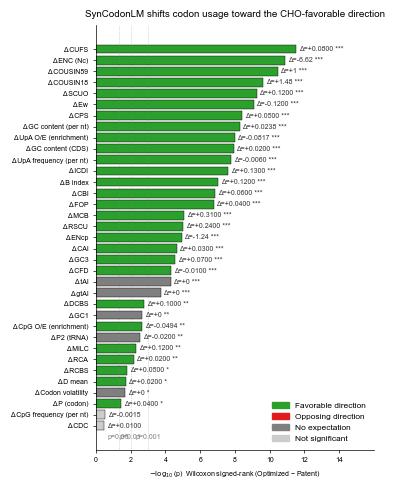

Saved: Figure_SynCodonLM_Direction_Summary.svg

=== Headline counts ===
Total metrics:          35
  Significant (p<0.05): 33  (94%)
  Favorable direction:  28
  Opposing direction:   0
  No expectation:       5
  Not significant:      2


In [66]:
# ============================================================
# Single-panel summary of SynCodonLM's directional impact
# Styled to match the waterfall SVG conventions.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# -----------------------------
# Input / output
# -----------------------------
SUMMARY_CSV = "AllMetrics_Patent_vs_Optimized_summary.csv"
OUT_FIG     = "Figure_SynCodonLM_Direction_Summary.svg"

CHAIN_FILTER = "All"

# -----------------------------
# SVG / figure styling (matches waterfall figure)
# -----------------------------
MM_TO_INCH = 1 / 25.4

FIG_WIDTH_MM   = 100          # match waterfall width
ROW_HEIGHT_MM  = 3.0         # vertical space per metric bar
MIN_HEIGHT_MM  = 80          # floor so tiny inputs still look ok
TOP_PAD_MM     = 12          # room for title
BOTTOM_PAD_MM  = 10          # room for x label

FONT_NAME          = "Arial"
TITLE_FONTSIZE     = 7
AXIS_FONTSIZE      = 5
TICK_FONTSIZE      = 5
TEXT_FONTSIZE      = 5
LEGEND_FONTSIZE    = 6

# Keep SVG text editable rather than converting fonts to paths
plt.rcParams["svg.fonttype"]  = "none"
plt.rcParams["font.family"]   = FONT_NAME
plt.rcParams["pdf.fonttype"]  = 42   # harmless, keeps text if you also save PDF

# -----------------------------
# Biological direction expectations
# -----------------------------
FAVORABLE_DIRECTION = {
    "CpG O/E (enrichment)":   -1,
    "UpA O/E (enrichment)":   -1,
    "CpG frequency (per nt)": -1,
    "UpA frequency (per nt)": -1,
    "GC content (per nt)":    +1,
    "GC content (CDS)":       +1,
    "GC1":                    +1,
    "GC2":                     0,
    "GC3":                    +1,
    "CAI":      +1,
    "FOP":      +1,
    "CBI":      +1,
    "RCA":      +1,
    "COUSIN18": +1,
    "COUSIN59": +1,
    "D mean":   +1,
    "CUFS":     +1,
    "B index":  +1,
    "CFD":      -1,
    "tAI":      +1,
    "gtAI":     +1,
    "P2 (tRNA)": 0,
    "RSCU":  +1,
    "ENC (Nc)": -1,
    "RCBS":  +1,
    "DCBS":  +1,
    "CDC":    0,
    "MILC":  +1,
    "ICDI":  +1,
    "SCUO":  +1,
    "Ew":    -1,
    "P (codon)": +1,
    "MCB":   +1,
    "ENcp":             -1,
    "CPS":              +1,
    "Codon volatility":  0,
}

# Colors
COLOR_MATCH    = "#2ca02c"
COLOR_OPPOSE   = "#e31a1c"
COLOR_NEUTRAL  = "#7f7f7f"
COLOR_NS       = "#cccccc"

# -----------------------------
# Load summary table
# -----------------------------
df = pd.read_csv(SUMMARY_CSV)
df = df[df["Chain"] == CHAIN_FILTER].copy()

if df.empty:
    raise ValueError(f"No rows with Chain == '{CHAIN_FILTER}' in {SUMMARY_CSV}")

df = df.dropna(subset=["p_value", "median_Delta"]).copy()

EPS = 1e-300
df["neg_log10_p"]  = -np.log10(df["p_value"].clip(lower=EPS))
df["observed_dir"] = np.sign(df["median_Delta"])
df["favorable_dir"] = df["Metric"].map(FAVORABLE_DIRECTION).fillna(0).astype(int)

def classify(row):
    if row["p_value"] >= 0.05:
        return "ns"
    if row["favorable_dir"] == 0:
        return "neutral"
    if row["observed_dir"] == row["favorable_dir"]:
        return "match"
    if row["observed_dir"] == -row["favorable_dir"]:
        return "oppose"
    return "neutral"

df["classification"] = df.apply(classify, axis=1)
df = df.sort_values("neg_log10_p", ascending=True).reset_index(drop=True)

# -----------------------------
# Figure sizing (mm-based, matching waterfall style)
# -----------------------------
n = len(df)
fig_height_mm = max(MIN_HEIGHT_MM, TOP_PAD_MM + BOTTOM_PAD_MM + ROW_HEIGHT_MM * n)
FIGSIZE = (FIG_WIDTH_MM * MM_TO_INCH, fig_height_mm * MM_TO_INCH)

fig, ax = plt.subplots(figsize=FIGSIZE)

color_map = {
    "match":   COLOR_MATCH,
    "oppose":  COLOR_OPPOSE,
    "neutral": COLOR_NEUTRAL,
    "ns":      COLOR_NS,
}
colors = [color_map[c] for c in df["classification"]]

# Prepend a delta sign and a space to every descriptor label
delta_labels = ["Δ " + str(name) for name in df["Metric"]]

ax.barh(
    delta_labels,
    df["neg_log10_p"],
    color=colors,
    edgecolor="black",
    linewidth=0.3,
)

# Annotations: signed median Δ + significance stars
for y, (med, p) in enumerate(zip(df["median_Delta"], df["p_value"])):
    if   p < 0.001: stars = "***"
    elif p < 0.01:  stars = "**"
    elif p < 0.05:  stars = "*"
    else:           stars = ""
    if abs(med) >= 1 or abs(med) < 1e-3:
        label = f"Δ={med:+.3g} {stars}"
    else:
        label = f"Δ={med:+.4f} {stars}"
    ax.text(
        df["neg_log10_p"].iloc[y] + 0.15,
        y,
        label,
        va="center",
        fontsize=TEXT_FONTSIZE,
        fontname=FONT_NAME,
        color="#333333",
    )

# Significance threshold guides
for thresh, lbl in [(-np.log10(0.05),  "p=0.05"),
                    (-np.log10(0.01),  "p=0.01"),
                    (-np.log10(0.001), "p=0.001")]:
    ax.axvline(thresh, linestyle=":", color="gray", linewidth=0.5, alpha=0.6)
    ax.text(
        thresh, -0.7, lbl,
        fontsize=TEXT_FONTSIZE,
        fontname=FONT_NAME,
        ha="center", va="top", color="gray",
    )

# Labels / title
ax.set_xlabel(
    "$-\\log_{10}$(p)  Wilcoxon signed-rank (Optimized − Patent)",
    fontsize=AXIS_FONTSIZE,
    fontname=FONT_NAME,
)
ax.set_title(
    "SynCodonLM shifts codon usage toward the CHO-favorable direction",
    fontsize=TITLE_FONTSIZE,
    fontname=FONT_NAME,
)

# Legend
legend_handles = [
    mpatches.Patch(color=COLOR_MATCH,   label="Favorable direction"),
    mpatches.Patch(color=COLOR_OPPOSE,  label="Opposing direction"),
    mpatches.Patch(color=COLOR_NEUTRAL, label="No expectation"),
    mpatches.Patch(color=COLOR_NS,      label="Not significant"),
]
leg = ax.legend(
    handles=legend_handles,
    loc="lower right",
    fontsize=LEGEND_FONTSIZE,
    frameon=False,
)
for txt in leg.get_texts():
    txt.set_fontname(FONT_NAME)

# Spines & ticks styled like the waterfall
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=TICK_FONTSIZE,
    width=0.5,
    length=2,
)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname(FONT_NAME)
    label.set_fontsize(TICK_FONTSIZE)

# X-axis padding for annotation text
max_x = df["neg_log10_p"].max()
ax.set_xlim(0, max_x * 1.30 + 1)

plt.tight_layout()

fig.savefig(OUT_FIG, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_FIG}")

# -----------------------------
# Headline counts
# -----------------------------
print("\n=== Headline counts ===")
total     = len(df)
n_sig     = (df["p_value"] < 0.05).sum()
n_match   = (df["classification"] == "match").sum()
n_oppose  = (df["classification"] == "oppose").sum()
n_neutral = (df["classification"] == "neutral").sum()
n_ns      = (df["classification"] == "ns").sum()
print(f"Total metrics:          {total}")
print(f"  Significant (p<0.05): {n_sig}  ({100*n_sig/total:.0f}%)")
print(f"  Favorable direction:  {n_match}")
print(f"  Opposing direction:   {n_oppose}")
print(f"  No expectation:       {n_neutral}")
print(f"  Not significant:      {n_ns}")

Supplementary Figure 6

Mean n: 23


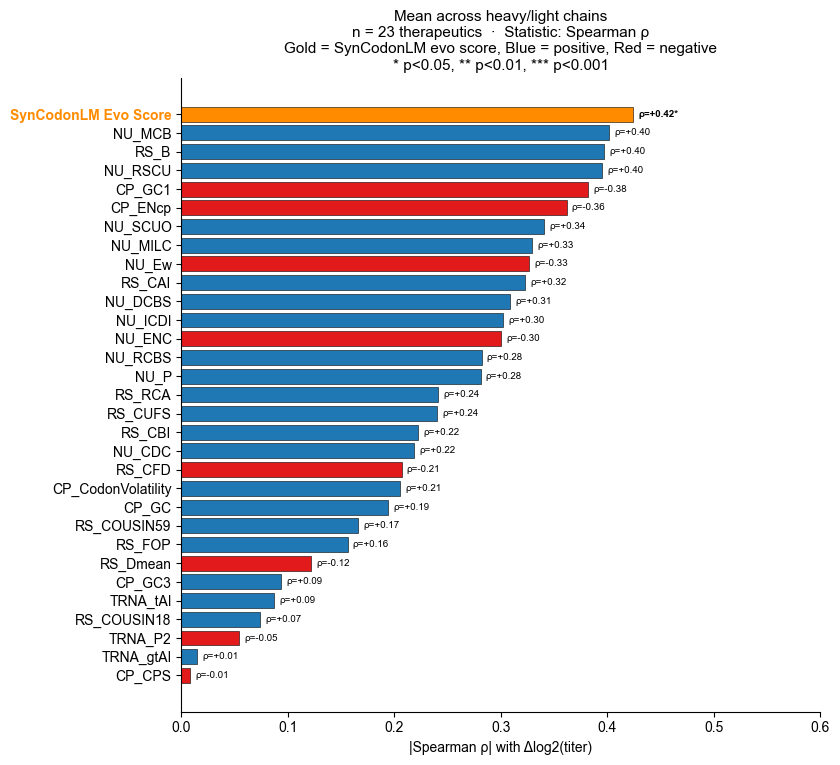


=== Mean grouping (Spearman ρ) ===
Evo score rank: 1 of 31
Evo score ρ = +0.424, p = 4.38e-02

Top 5 metrics (incl. evo):
 Rank               Metric  Spearman ρ  p_value  n
    1 SynCodonLM Evo Score    0.423913 0.043816 23
    2               NU_MCB    0.401384 0.057652 23
    3                 RS_B    0.397033 0.060673 23
    4              NU_RSCU    0.395056 0.062086 23
    5               CP_GC1   -0.381596 0.072382 23


In [ ]:
CORRELATION_METRIC = "spearman"  # "pearson" | "spearman" | "r2"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import re

# -----------------------------
# Input files
# -----------------------------
TITER_FILE = "master-data.xlsx"
STATS_FILE = "heuristic-statistical-descriptors.xlsx"
SCORE_FILE = "patented+mutated-sequences-with-evo-scores.xlsx"
STATS_SHEET = "All_Data"

# -----------------------------
# Settings
# -----------------------------
ID_COL = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"
TOO_LOW_AS = np.nan

TITER_PATTERN = r"^Titer\s*mg/L\s*Rep\s*\d+$"

ORIG_SCORE_COL = "Original_DNA_synonym_constrained_mean_logprob"
OPT_SCORE_COL  = "Optimized_DNA_synonym_constrained_mean_logprob"
EVO_METRIC_NAME = "SynCodonLM Evo Score"

NON_METRIC_COLS = {
    "Chain", "File", "Gene", "Reference Source",
    "Expression Host Organism", "DNA Sequence Length (reported)"
}

# Color scheme
COLOR_POS = "#1f78b4"  # blue, positive correlation
COLOR_NEG = "#e31a1c"  # red, negative correlation
COLOR_EVO = "#ff8c00"  # gold, evo score

# -----------------------------
# Correlation metric config
# -----------------------------
CORRELATION_METRIC = CORRELATION_METRIC.lower()
assert CORRELATION_METRIC in {"pearson", "spearman", "r2"}, \
    "CORRELATION_METRIC must be 'pearson', 'spearman', or 'r2'"

METRIC_INFO = {
    "pearson": {
        "stat_label":   "Pearson r",
        "abs_label":    "|Pearson r|",
        "value_prefix": "r",
        "signed":       True,
        "func":         lambda x, y: pearsonr(x, y),
    },
    "spearman": {
        "stat_label":   "Spearman ρ",
        "abs_label":    "|Spearman ρ|",
        "value_prefix": "ρ",
        "signed":       True,
        "func":         lambda x, y: spearmanr(x, y),
    },
    "r2": {
        "stat_label":   "R²",
        "abs_label":    "R²",
        "value_prefix": "R²",
        "signed":       False,  # R² is always non-negative; we track sign of underlying r for color
        "func":         lambda x, y: pearsonr(x, y),  # we compute r then square
    },
}
CFG = METRIC_INFO[CORRELATION_METRIC]

GROUP_TITLE = "Mean across heavy/light chains"

# -----------------------------
# Helpers
# -----------------------------
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({
            "Too Low": TOO_LOW_AS, "too low": TOO_LOW_AS, "TOO LOW": TOO_LOW_AS,
            "": np.nan, " ": np.nan, "NA": np.nan, "na": np.nan
        }),
        errors="coerce"
    )

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

def get_chain_group(chain_id):
    s = str(chain_id).strip().lower()
    if s.startswith("heavy"):
        return "Heavy"
    if s.startswith("light"):
        return "Light"
    return "Other"

def compute_stat(x, y):
    """
    Returns (signed_stat, plot_value, sign, p_value).
      signed_stat: signed correlation (for tables/printing)
      plot_value : value plotted on the bar (|r|, |ρ|, or R²)
      sign       : +1 or -1 (used for bar color)
      p_value    : underlying p
    """
    r, p = CFG["func"](x, y)
    sign = 1 if r >= 0 else -1
    if CORRELATION_METRIC == "r2":
        plot_value = r ** 2
        signed_stat = r ** 2  # always positive
    else:
        plot_value = abs(r)
        signed_stat = r
    return signed_stat, plot_value, sign, p

# -----------------------------
# 1) Titer log2FC per therapeutic
# -----------------------------
df = pd.read_excel(TITER_FILE, engine="openpyxl")
df = df.dropna(subset=[ID_COL]).copy()
df[ID_COL] = df[ID_COL].astype(str).str.strip()

parsed = df[ID_COL].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)
df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()
df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

titer_cols = sorted(
    [c for c in df.columns if re.match(TITER_PATTERN, str(c).strip(), re.IGNORECASE)],
    key=rep_num
)
for c in titer_cols:
    df[c] = clean_numeric(df[c])

df["Titer_row_mean"] = df[titer_cols].mean(axis=1, skipna=True)

titer_long = (
    df.groupby(["Base_Molecule", "Variant"], dropna=False)
      .agg(Titer_Mean=("Titer_row_mean", "mean"))
      .reset_index()
)
titer_wide = titer_long.pivot(
    index="Base_Molecule", columns="Variant", values="Titer_Mean"
).reset_index()

for v in [PARENT_LABEL, MUT_LABEL]:
    if v not in titer_wide.columns:
        titer_wide[v] = np.nan

pos_vals = titer_wide[[PARENT_LABEL, MUT_LABEL]].values.flatten()
pos_vals = pos_vals[np.isfinite(pos_vals) & (pos_vals > 0)]
eps = 0.01 * np.min(pos_vals) if len(pos_vals) else 1e-6

titer_wide["Titer_log2FC"] = np.log2(
    (titer_wide[MUT_LABEL] + eps) / (titer_wide[PARENT_LABEL] + eps)
)
titer_wide = titer_wide.rename(columns={"Base_Molecule": "Therapeutic"})
titer_wide = titer_wide[["Therapeutic", "Titer_log2FC"]]

# -----------------------------
# 2) Stats file
# -----------------------------
stats = pd.read_excel(STATS_FILE, sheet_name=STATS_SHEET, engine="openpyxl")
stats["Chain"] = stats["Chain"].astype(str).str.strip()

chain_parsed = stats["Chain"].str.extract(
    r"^(?P<Therapeutic>.+?)\s+(?P<ChainID>(?:Heavy|Light)\s*\d+)\s+(?P<Variant>Patent|Mutated)\s*$",
    flags=re.IGNORECASE
)
stats["Therapeutic"] = chain_parsed["Therapeutic"].str.strip()
stats["ChainID"] = (
    chain_parsed["ChainID"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.title()
)
stats["Variant"] = chain_parsed["Variant"].str.capitalize()
stats["Chain_Group"] = stats["ChainID"].apply(get_chain_group)
stats = stats.dropna(subset=["Therapeutic", "ChainID", "Variant"]).copy()
stats = stats[stats["Chain_Group"].isin(["Heavy", "Light"])].copy()

metric_cols = [
    c for c in stats.columns
    if c not in NON_METRIC_COLS
    and c not in {"Therapeutic", "ChainID", "Variant", "Chain_Group"}
]
for c in metric_cols:
    stats[c] = clean_numeric(stats[c])
metric_cols = [c for c in metric_cols if stats[c].notna().sum() > 0]

# -----------------------------
# 3) Evo score file
# -----------------------------
score_df = pd.read_excel(SCORE_FILE, sheet_name="Scored_Sequences", engine="openpyxl")
score_df["Therapeutic"] = score_df["Therapeutic"].astype(str).str.strip()
score_df["Chain"] = score_df["Chain"].astype(str).str.strip()
score_df["Chain_Group"] = score_df["Chain"].apply(get_chain_group)
for c in [ORIG_SCORE_COL, OPT_SCORE_COL]:
    score_df[c] = pd.to_numeric(score_df[c], errors="coerce")
score_df[EVO_METRIC_NAME] = score_df[OPT_SCORE_COL] - score_df[ORIG_SCORE_COL]
score_df = score_df[score_df["Chain_Group"].isin(["Heavy", "Light"])].copy()

# -----------------------------
# 4) Per-chain Δ for classical metrics
#    (Heavy + Light per-chain deltas are still needed as the
#     building blocks that get averaged into the "Mean" grouping)
# -----------------------------
per_chain_rows = []
for (ther, cid, cg, var), sub in stats.groupby(
    ["Therapeutic", "ChainID", "Chain_Group", "Variant"]
):
    rec = {"Therapeutic": ther, "ChainID": cid, "Chain_Group": cg, "Variant": var}
    for c in metric_cols:
        rec[c] = sub[c].mean()
    per_chain_rows.append(rec)
per_chain = pd.DataFrame(per_chain_rows)

delta_rows = []
for (ther, cid, cg), sub in per_chain.groupby(["Therapeutic", "ChainID", "Chain_Group"]):
    pat = sub[sub["Variant"] == PARENT_LABEL]
    mut = sub[sub["Variant"] == MUT_LABEL]
    if len(pat) == 0 or len(mut) == 0:
        continue
    rec = {"Therapeutic": ther, "ChainID": cid, "Chain_Group": cg}
    for c in metric_cols:
        rec[c] = mut[c].values[0] - pat[c].values[0]
    delta_rows.append(rec)
chain_delta_df = pd.DataFrame(delta_rows)

# -----------------------------
# 5) Mean-across-chains aggregation only
# -----------------------------
classical_mean = chain_delta_df.groupby("Therapeutic", as_index=False)[metric_cols].mean()
evo_mean = score_df.groupby("Therapeutic", as_index=False)[EVO_METRIC_NAME].mean()

merged = (
    titer_wide
    .merge(classical_mean, on="Therapeutic", how="inner")
    .merge(evo_mean, on="Therapeutic", how="inner")
)
print(f"Mean n: {len(merged)}")

all_metric_names = metric_cols + [EVO_METRIC_NAME]

# -----------------------------
# 6) Correlation table (Mean grouping only)
# -----------------------------
def corr_table(merged, label):
    rows = []
    for c in all_metric_names:
        if c not in merged.columns:
            continue
        d = merged[["Titer_log2FC", c]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(d) < 3 or d[c].nunique() < 2:
            continue
        signed_stat, plot_value, sign, p = compute_stat(d[c].values, d["Titer_log2FC"].values)
        rows.append({
            "Grouping": label,
            "Metric": c,
            "Stat_signed": signed_stat,
            "Plot_value": plot_value,
            "Sign": sign,
            "p_value": p,
            "n": len(d),
        })
    return pd.DataFrame(rows)

results_mean = corr_table(merged, "Mean")

# -----------------------------
# 7) Single bar chart (Mean grouping) - display only, no save
# -----------------------------
def fmt_value(signed_stat, sign):
    """Format the numerical annotation on each bar."""
    prefix = CFG["value_prefix"]
    if CORRELATION_METRIC == "r2":
        # R² is unsigned; show sign of underlying r in parens for color context
        return f"{prefix}={signed_stat:.2f}"
    else:
        return f"{prefix}={signed_stat:+.2f}"

def plot_grouping(res_df, merged_df, title):
    d = res_df.copy()
    d = d.sort_values("Plot_value", ascending=True)  # biggest at top

    n_used = len(merged_df)

    fig, ax = plt.subplots(figsize=(8.5, max(5, 0.25 * len(d))))

    colors = []
    for metric, sign in zip(d["Metric"], d["Sign"]):
        if metric == EVO_METRIC_NAME:
            colors.append(COLOR_EVO)
        elif sign < 0:
            colors.append(COLOR_NEG)
        else:
            colors.append(COLOR_POS)

    ax.barh(
        d["Metric"], d["Plot_value"],
        color=colors, edgecolor="black", linewidth=0.4
    )

    # Bold evo score label
    for tick_label in ax.get_yticklabels():
        if tick_label.get_text() == EVO_METRIC_NAME:
            tick_label.set_fontweight("bold")
            tick_label.set_color(COLOR_EVO)

    # Bar annotations
    for y, (metric, signed_stat, sign, pv, p) in enumerate(zip(
        d["Metric"], d["Stat_signed"], d["Sign"], d["Plot_value"], d["p_value"]
    )):
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        weight = "bold" if metric == EVO_METRIC_NAME else "normal"
        ax.text(
            pv + 0.005, y, f"{fmt_value(signed_stat, sign)}{sig}",
            va="center", fontsize=7, fontweight=weight
        )

    ax.set_xlabel(f"{CFG['abs_label']} with Δlog2(titer)")
    if CORRELATION_METRIC == "r2":
        legend_line = "Gold = SynCodonLM evo score, Blue = positive underlying r, Red = negative underlying r"
    else:
        legend_line = "Gold = SynCodonLM evo score, Blue = positive, Red = negative"

    ax.set_title(
        f"{title}\n"
        f"n = {n_used} therapeutics  ·  Statistic: {CFG['stat_label']}\n"
        f"{legend_line}\n"
        f"* p<0.05, ** p<0.01, *** p<0.001",
        fontsize=11
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, max(0.6, d["Plot_value"].max() * 1.25))

    plt.tight_layout()
    plt.show()

plot_grouping(res_df=results_mean, merged_df=merged, title=GROUP_TITLE)

# -----------------------------
# 8) Console preview: where does evo rank?
# -----------------------------
ranked = results_mean.sort_values("Plot_value", ascending=False).reset_index(drop=True)
ranked["Rank"] = ranked.index + 1
evo_row = ranked[ranked["Metric"] == EVO_METRIC_NAME]
if len(evo_row):
    print(f"\n=== Mean grouping ({CFG['stat_label']}) ===")
    print(f"Evo score rank: {evo_row['Rank'].values[0]} of {len(ranked)}")
    print(f"Evo score {CFG['value_prefix']} = {evo_row['Stat_signed'].values[0]:+.3f}, "
          f"p = {evo_row['p_value'].values[0]:.2e}")
    top = ranked.head(5)[["Rank", "Metric", "Stat_signed", "p_value", "n"]].rename(
        columns={"Stat_signed": CFG["stat_label"]}
    )
    print("\nTop 5 metrics (incl. evo):")
    print(top.to_string(index=False))


Figure 5b

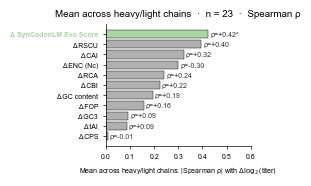

Saved: Figure_FamousMetrics_plus_Evo_SpearmanRho_Mean.svg


In [68]:
# ============================================================
# Mean across heavy/light chains — famous codon metrics + Evo
# Nature-submission SVG styling to match the waterfall figure.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# SVG / figure styling (matches waterfall)
# -----------------------------
MM_TO_INCH = 1 / 25.4

FIG_WIDTH_MM  = 70
FIG_HEIGHT_MM = 50

FONT_NAME       = "Arial"
TITLE_FONTSIZE  = 7
AXIS_FONTSIZE   = 5
TICK_FONTSIZE   = 5
TEXT_FONTSIZE   = 5

# Colors — classical metrics neutral gray, SynCodonLM pastel green
COLOR_CLASSICAL = "#b0b0b0"   # neutral gray
COLOR_EVO       = "#a8d5a2"   # pastel green

# Keep SVG text editable
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"]  = FONT_NAME
plt.rcParams["pdf.fonttype"] = 42

# -----------------------------
# Local, self-contained stat config
# (renamed from CFG -> PLOT_CFG on purpose: this notebook reuses the
#  variable name "CFG" for unrelated things elsewhere, e.g. fine-tuning
#  configs, which was clobbering the stats CFG dict and caused
#  KeyError: 'file_suffix'. Rebuilding it locally here avoids that clash.)
# -----------------------------
_METRIC_INFO = {
    "pearson":  {"stat_label": "Pearson r",  "abs_label": "|Pearson r|", "value_prefix": "r",  "file_suffix": "PearsonR"},
    "spearman": {"stat_label": "Spearman ρ", "abs_label": "|Spearman ρ|", "value_prefix": "ρ", "file_suffix": "SpearmanRho"},
    "r2":       {"stat_label": "R²",         "abs_label": "R²",          "value_prefix": "R²", "file_suffix": "R2"},
}
PLOT_CFG = _METRIC_INFO[CORRELATION_METRIC.lower()]
CFG = PLOT_CFG  # keep name CFG available for the f-strings below, now guaranteed correct

OUT_FIG = f"Figure_FamousMetrics_plus_Evo_{CFG['file_suffix']}_Mean.svg"

# -----------------------------
# Data
# (uses res_mean / merged_mean, which is what the refactored
#  mean-only pipeline actually produces — the old
#  results_by_group / merged_by_group dicts no longer exist)
# -----------------------------
res_df    = res_mean.copy()
merged_df = merged_mean
n_used    = len(merged_df)
evo_display = DISPLAY_NAMES.get(EVO_METRIC_NAME, EVO_METRIC_NAME)

d = res_df.sort_values("Plot_value", ascending=True).reset_index(drop=True)

# -----------------------------
# Formatting helpers
# -----------------------------
def fmt_value(signed_stat):
    prefix = CFG["value_prefix"]
    if CORRELATION_METRIC == "r2":
        return f"{prefix}={signed_stat:.2f}"
    return f"{prefix}={signed_stat:+.2f}"

def sig_stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

# -----------------------------
# Figure
# -----------------------------
FIGSIZE = (FIG_WIDTH_MM * MM_TO_INCH, FIG_HEIGHT_MM * MM_TO_INCH)
fig, ax = plt.subplots(figsize=FIGSIZE)

colors = [
    COLOR_EVO if metric == EVO_METRIC_NAME else COLOR_CLASSICAL
    for metric in d["Metric"]
]

# Prepend a delta sign and a space to every descriptor label
delta_labels = ["Δ " + str(name) for name in d["Display"]]

ax.barh(
    delta_labels, d["Plot_value"],
    color=colors, edgecolor="black", linewidth=0.3,
)

# Bold evo score label
for tick_label in ax.get_yticklabels():
    if tick_label.get_text() == "Δ " + str(evo_display):
        tick_label.set_fontweight("bold")
        tick_label.set_color(COLOR_EVO)

# Bar annotations — uniform styling for all bars
for y, (signed_stat, pv, p) in enumerate(zip(
    d["Stat_signed"], d["Plot_value"], d["p_value"]
)):
    ax.text(
        pv + 0.008, y,
        f"{fmt_value(signed_stat)}{sig_stars(p)}",
        va="center",
        fontsize=TEXT_FONTSIZE,
        fontname=FONT_NAME,
        color="#333333",
    )

# Labels / title
ax.set_xlabel(
    f"Mean across heavy/light chains: {CFG['abs_label']} with $\\Delta\\log_{{2}}$(titer)",
    fontsize=AXIS_FONTSIZE,
    fontname=FONT_NAME,
)
ax.set_title(
    f"Mean across heavy/light chains  ·  n = {n_used}  ·  {CFG['stat_label']}",
    fontsize=TITLE_FONTSIZE,
    fontname=FONT_NAME,
)

# Spines & ticks (waterfall style)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

ax.tick_params(
    axis="both", which="major",
    labelsize=TICK_FONTSIZE, width=0.5, length=2,
)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname(FONT_NAME)
    label.set_fontsize(TICK_FONTSIZE)

ax.set_xlim(0, max(0.6, d["Plot_value"].max() * 1.35))

plt.tight_layout()
fig.savefig(OUT_FIG, format="svg", bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_FIG}")


Supplementary Figure 7

Mean n: 23

Running bootstrap with 5000 resamples per metric...

Saved: FamousMetrics_plus_Evo_vs_Titer_correlations_SpearmanRho_withCI.csv


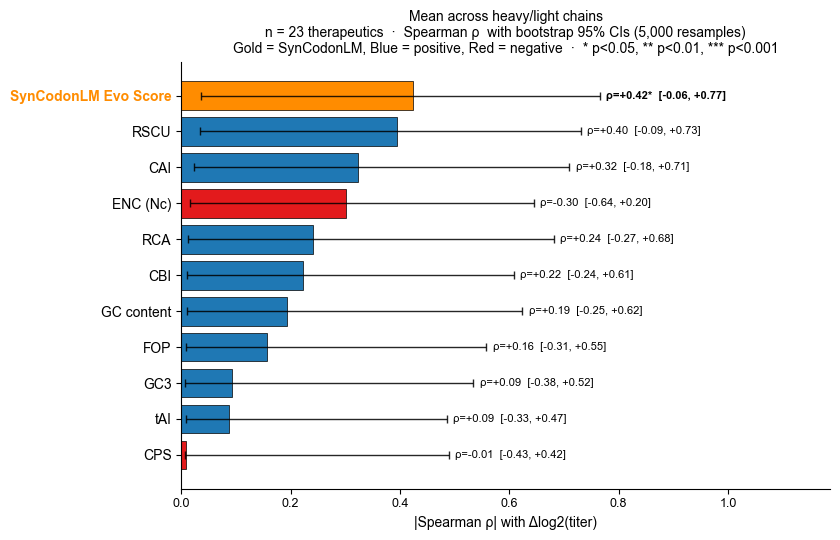


=== Mean grouping (Spearman ρ) ===
 Rank              Display  Spearman ρ    CI_low  CI_high  p_value  CI_excludes_zero  n
    1 SynCodonLM Evo Score    0.423913 -0.058184 0.765543 0.043816             False 23
    2                 RSCU    0.395056 -0.092370 0.730813 0.062086             False 23
    3                  CAI    0.322638 -0.181253 0.709218 0.133221             False 23
    4             ENC (Nc)   -0.300395 -0.643970 0.202000 0.163705             False 23
    5                  RCA    0.241269 -0.274486 0.681002 0.267411             False 23
    6                  CBI    0.222112 -0.241650 0.607697 0.308390             False 23
    7           GC content    0.193931 -0.251805 0.623484 0.375265             False 23
    8                  FOP    0.156018 -0.307343 0.553450 0.477157             False 23
    9                  GC3    0.093565 -0.378601 0.520683 0.671107             False 23
   10                  tAI    0.086896 -0.330201 0.474592 0.693401             False

In [79]:
# ============================================================
# Δlog2(titer) vs Δ(famous classical metrics) + SynCodonLM evo score
# WITH BOOTSTRAP 95% CONFIDENCE INTERVALS as error bars
# Select correlation statistic at the top.
# ============================================================

CORRELATION_METRIC = "spearman"   # "pearson" | "spearman" | "r2"
N_BOOTSTRAP = 5000                # bootstrap resamples
RNG_SEED = 9

# -----------------------------
# Curated famous-metrics list
# -----------------------------
FAMOUS_METRICS = [
    "RS_CAI",       # Codon Adaptation Index
    "TRNA_tAI",     # tRNA Adaptation Index
    "NU_ENC",       # Effective Number of Codons
    "RS_FOP",       # Frequency of Optimal Codons
    "RS_CBI",       # Codon Bias Index
    "NU_RSCU",      # Relative Synonymous Codon Usage
    "CP_GC",        # GC content
    "CP_GC3",       # GC content at 3rd position
    "CP_CPS",       # Codon Pair Score
    "RS_RCA",       # Relative Codon Adaptation
]

DISPLAY_NAMES = {
    "RS_CAI":  "CAI",
    "TRNA_tAI": "tAI",
    "NU_ENC":  "ENC (Nc)",
    "RS_FOP":  "FOP",
    "RS_CBI":  "CBI",
    "NU_RSCU": "RSCU",
    "CP_GC":   "GC content",
    "CP_GC3":  "GC3",
    "CP_CPS":  "CPS",
    "RS_RCA":  "RCA",
}

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import re

# -----------------------------
# Input files
# -----------------------------
TITER_FILE = "master-data.xlsx"
STATS_FILE = "heuristic-statistical-descriptors.xlsx"
SCORE_FILE = "patented+mutated-sequences-with-evo-scores.xlsx"
STATS_SHEET = "All_Data"

# -----------------------------
# Settings
# -----------------------------
ID_COL = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL = "Mutated"
TOO_LOW_AS = np.nan

TITER_PATTERN = r"^Titer\s*mg/L\s*Rep\s*\d+$"

ORIG_SCORE_COL = "Original_DNA_synonym_constrained_mean_logprob"
OPT_SCORE_COL  = "Optimized_DNA_synonym_constrained_mean_logprob"
EVO_METRIC_NAME = "SynCodonLM Evo Score"

COLOR_POS = "#1f78b4"
COLOR_NEG = "#e31a1c"
COLOR_EVO = "#ff8c00"

# -----------------------------
# Correlation metric config
# -----------------------------
CORRELATION_METRIC = CORRELATION_METRIC.lower()
assert CORRELATION_METRIC in {"pearson", "spearman", "r2"}

METRIC_INFO = {
    "pearson": {
        "stat_label":   "Pearson r",
        "abs_label":    "|Pearson r|",
        "value_prefix": "r",
        "func":         lambda x, y: pearsonr(x, y)[0],
        "p_func":       lambda x, y: pearsonr(x, y)[1],
        "file_suffix":  "PearsonR_withCI",
    },
    "spearman": {
        "stat_label":   "Spearman ρ",
        "abs_label":    "|Spearman ρ|",
        "value_prefix": "ρ",
        "func":         lambda x, y: spearmanr(x, y)[0],
        "p_func":       lambda x, y: spearmanr(x, y)[1],
        "file_suffix":  "SpearmanRho_withCI",
    },
    "r2": {
        "stat_label":   "R²",
        "abs_label":    "R²",
        "value_prefix": "R²",
        "func":         lambda x, y: pearsonr(x, y)[0],
        "p_func":       lambda x, y: pearsonr(x, y)[1],
        "file_suffix":  "R2_withCI",
    },
}
CFG = METRIC_INFO[CORRELATION_METRIC]

GROUP_TITLE = "Mean across heavy/light chains"

OUT_TABLE = f"FamousMetrics_plus_Evo_vs_Titer_correlations_{CFG['file_suffix']}.csv"

# -----------------------------
# Helpers
# -----------------------------
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({
            "Too Low": TOO_LOW_AS, "too low": TOO_LOW_AS, "TOO LOW": TOO_LOW_AS,
            "": np.nan, " ": np.nan, "NA": np.nan, "na": np.nan
        }),
        errors="coerce"
    )

def rep_num(colname):
    m = re.search(r"(\d+)", str(colname))
    return int(m.group(1)) if m else 999

def get_chain_group(chain_id):
    s = str(chain_id).strip().lower()
    if s.startswith("heavy"):
        return "Heavy"
    if s.startswith("light"):
        return "Light"
    return "Other"

def stat_from_r(r):
    """Transform raw Pearson/Spearman r into the chosen plotted statistic."""
    if CORRELATION_METRIC == "r2":
        return r ** 2
    return r  # signed for pearson/spearman

def compute_point_estimate(x, y):
    r = CFG["func"](x, y)
    p = CFG["p_func"](x, y)
    signed_stat = stat_from_r(r)
    plot_value = abs(signed_stat) if CORRELATION_METRIC != "r2" else signed_stat
    sign = 1 if r >= 0 else -1
    return signed_stat, plot_value, sign, p, r

def bootstrap_ci(x, y, n_boot=N_BOOTSTRAP, seed=RNG_SEED, alpha=0.05):
    rng = np.random.default_rng(seed)
    n = len(x)
    if n < 4:
        return (np.nan,) * 4

    x = np.asarray(x); y = np.asarray(y)
    boot_signed = np.empty(n_boot)
    boot_plot   = np.empty(n_boot)

    valid = 0
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)
        xb, yb = x[idx], y[idx]
        if np.unique(xb).size < 2 or np.unique(yb).size < 2:
            boot_signed[i] = np.nan
            boot_plot[i]   = np.nan
            continue
        try:
            rb = CFG["func"](xb, yb)
        except Exception:
            boot_signed[i] = np.nan
            boot_plot[i]   = np.nan
            continue
        sb = stat_from_r(rb)
        boot_signed[i] = sb
        boot_plot[i]   = abs(sb) if CORRELATION_METRIC != "r2" else sb
        valid += 1

    if valid < 100:
        return (np.nan,) * 4

    lo, hi = 100 * alpha / 2, 100 * (1 - alpha / 2)
    return (
        np.nanpercentile(boot_signed, lo),
        np.nanpercentile(boot_signed, hi),
        np.nanpercentile(boot_plot, lo),
        np.nanpercentile(boot_plot, hi),
    )

# -----------------------------
# 1) Titer log2FC per therapeutic
# -----------------------------
df = pd.read_excel(TITER_FILE, engine="openpyxl")
df = df.dropna(subset=[ID_COL]).copy()
df[ID_COL] = df[ID_COL].astype(str).str.strip()

parsed = df[ID_COL].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE
)
df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"] = parsed["Variant"].str.capitalize()
df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

titer_cols = sorted(
    [c for c in df.columns if re.match(TITER_PATTERN, str(c).strip(), re.IGNORECASE)],
    key=rep_num
)
for c in titer_cols:
    df[c] = clean_numeric(df[c])
df["Titer_row_mean"] = df[titer_cols].mean(axis=1, skipna=True)

titer_long = (
    df.groupby(["Base_Molecule", "Variant"], dropna=False)
      .agg(Titer_Mean=("Titer_row_mean", "mean"))
      .reset_index()
)
titer_wide = titer_long.pivot(
    index="Base_Molecule", columns="Variant", values="Titer_Mean"
).reset_index()
for v in [PARENT_LABEL, MUT_LABEL]:
    if v not in titer_wide.columns:
        titer_wide[v] = np.nan
pos_vals = titer_wide[[PARENT_LABEL, MUT_LABEL]].values.flatten()
pos_vals = pos_vals[np.isfinite(pos_vals) & (pos_vals > 0)]
eps = 0.01 * np.min(pos_vals) if len(pos_vals) else 1e-6
titer_wide["Titer_log2FC"] = np.log2(
    (titer_wide[MUT_LABEL] + eps) / (titer_wide[PARENT_LABEL] + eps)
)
titer_wide = titer_wide.rename(columns={"Base_Molecule": "Therapeutic"})
titer_wide = titer_wide[["Therapeutic", "Titer_log2FC"]]

# -----------------------------
# 2) Stats file - restrict to famous metrics
# -----------------------------
stats = pd.read_excel(STATS_FILE, sheet_name=STATS_SHEET, engine="openpyxl")
stats["Chain"] = stats["Chain"].astype(str).str.strip()

chain_parsed = stats["Chain"].str.extract(
    r"^(?P<Therapeutic>.+?)\s+(?P<ChainID>(?:Heavy|Light)\s*\d+)\s+(?P<Variant>Patent|Mutated)\s*$",
    flags=re.IGNORECASE
)
stats["Therapeutic"] = chain_parsed["Therapeutic"].str.strip()
stats["ChainID"] = (
    chain_parsed["ChainID"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
    .str.title()
)
stats["Variant"] = chain_parsed["Variant"].str.capitalize()
stats["Chain_Group"] = stats["ChainID"].apply(get_chain_group)
stats = stats.dropna(subset=["Therapeutic", "ChainID", "Variant"]).copy()
stats = stats[stats["Chain_Group"].isin(["Heavy", "Light"])].copy()

missing = [m for m in FAMOUS_METRICS if m not in stats.columns]
if missing:
    print(f"WARNING: missing metrics from stats file: {missing}")
metric_cols = [m for m in FAMOUS_METRICS if m in stats.columns]
for c in metric_cols:
    stats[c] = clean_numeric(stats[c])

# -----------------------------
# 3) Evo score file
# -----------------------------
score_df = pd.read_excel(SCORE_FILE, sheet_name="Scored_Sequences", engine="openpyxl")
score_df["Therapeutic"] = score_df["Therapeutic"].astype(str).str.strip()
score_df["Chain"] = score_df["Chain"].astype(str).str.strip()
score_df["Chain_Group"] = score_df["Chain"].apply(get_chain_group)
for c in [ORIG_SCORE_COL, OPT_SCORE_COL]:
    score_df[c] = pd.to_numeric(score_df[c], errors="coerce")
score_df[EVO_METRIC_NAME] = score_df[OPT_SCORE_COL] - score_df[ORIG_SCORE_COL]
score_df = score_df[score_df["Chain_Group"].isin(["Heavy", "Light"])].copy()

# -----------------------------
# 4) Per-chain Δ for classical metrics
# -----------------------------
per_chain_rows = []
for (ther, cid, cg, var), sub in stats.groupby(
    ["Therapeutic", "ChainID", "Chain_Group", "Variant"]
):
    rec = {"Therapeutic": ther, "ChainID": cid, "Chain_Group": cg, "Variant": var}
    for c in metric_cols:
        rec[c] = sub[c].mean()
    per_chain_rows.append(rec)
per_chain = pd.DataFrame(per_chain_rows)

delta_rows = []
for (ther, cid, cg), sub in per_chain.groupby(["Therapeutic", "ChainID", "Chain_Group"]):
    pat = sub[sub["Variant"] == PARENT_LABEL]
    mut = sub[sub["Variant"] == MUT_LABEL]
    if len(pat) == 0 or len(mut) == 0:
        continue
    rec = {"Therapeutic": ther, "ChainID": cid, "Chain_Group": cg}
    for c in metric_cols:
        rec[c] = mut[c].values[0] - pat[c].values[0]
    delta_rows.append(rec)
chain_delta_df = pd.DataFrame(delta_rows)

# Mean across heavy + light chains (no separate Heavy-only / Light-only grouping)
classical_mean = chain_delta_df.groupby("Therapeutic", as_index=False)[metric_cols].mean()
evo_mean = score_df.groupby("Therapeutic", as_index=False)[EVO_METRIC_NAME].mean()

merged = (
    titer_wide
    .merge(classical_mean, on="Therapeutic", how="inner")
    .merge(evo_mean, on="Therapeutic", how="inner")
)
print(f"Mean n: {len(merged)}")

all_metric_names = metric_cols + [EVO_METRIC_NAME]

# -----------------------------
# 5) Correlation table WITH bootstrap CIs (Mean grouping only)
# -----------------------------
print(f"\nRunning bootstrap with {N_BOOTSTRAP} resamples per metric...")

def corr_table_with_ci(merged, label):
    rows = []
    for c in all_metric_names:
        if c not in merged.columns:
            continue
        d = merged[["Titer_log2FC", c]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(d) < 4 or d[c].nunique() < 2:
            continue
        x = d[c].values
        y = d["Titer_log2FC"].values

        signed_stat, plot_value, sign, p, r_raw = compute_point_estimate(x, y)
        lo_s, hi_s, lo_p, hi_p = bootstrap_ci(x, y)

        display = DISPLAY_NAMES.get(c, c)
        rows.append({
            "Grouping":          label,
            "Metric":            c,
            "Display":           display,
            "Stat_signed":       signed_stat,
            "Plot_value":        plot_value,
            "CI_low_signed":     lo_s,
            "CI_high_signed":    hi_s,
            "CI_low_plot":       lo_p,
            "CI_high_plot":      hi_p,
            "Sign":              sign,
            "p_value":           p,
            "n":                 len(d),
            "CI_excludes_zero":  (lo_s > 0) or (hi_s < 0)
                                 if CORRELATION_METRIC != "r2"
                                 else lo_s > 0,
        })
    return pd.DataFrame(rows)

results = corr_table_with_ci(merged, "Mean")
results.to_csv(OUT_TABLE, index=False)
print(f"\nSaved: {OUT_TABLE}")

# -----------------------------
# 6) Mean-only bar chart with error bars (not saved to disk)
# -----------------------------
def fmt_value(signed_stat):
    prefix = CFG["value_prefix"]
    if CORRELATION_METRIC == "r2":
        return f"{prefix}={signed_stat:.2f}"
    return f"{prefix}={signed_stat:+.2f}"

def fmt_ci(lo, hi):
    if CORRELATION_METRIC == "r2":
        return f"[{lo:.2f}, {hi:.2f}]"
    return f"[{lo:+.2f}, {hi:+.2f}]"

def plot_grouping(res_df, merged_df, title):
    d = res_df.copy()
    d = d.sort_values("Plot_value", ascending=True)
    n_used = len(merged_df)
    evo_display = DISPLAY_NAMES.get(EVO_METRIC_NAME, EVO_METRIC_NAME)

    fig, ax = plt.subplots(figsize=(8.5, 5.5))

    colors = []
    for metric, sign in zip(d["Metric"], d["Sign"]):
        if metric == EVO_METRIC_NAME:
            colors.append(COLOR_EVO)
        elif sign < 0:
            colors.append(COLOR_NEG)
        else:
            colors.append(COLOR_POS)

    # Error bars: distance from bar end to CI bounds on the plotted scale
    plot_vals = d["Plot_value"].values
    lo_plot   = d["CI_low_plot"].values
    hi_plot   = d["CI_high_plot"].values

    # Asymmetric errors: clip so we never go below 0
    err_low  = np.clip(plot_vals - np.nan_to_num(lo_plot, nan=0), 0, None)
    err_high = np.clip(np.nan_to_num(hi_plot, nan=plot_vals) - plot_vals, 0, None)

    bars = ax.barh(
        d["Display"], plot_vals,
        color=colors, edgecolor="black", linewidth=0.5,
        xerr=[err_low, err_high],
        error_kw=dict(ecolor="black", lw=1.0, capsize=3, alpha=0.85)
    )

    for tick_label in ax.get_yticklabels():
        if tick_label.get_text() == evo_display:
            tick_label.set_fontweight("bold")
            tick_label.set_color(COLOR_EVO)

    # Annotations: point estimate + significance + CI
    for y, (metric, signed_stat, pv, hi, lo_s, hi_s, p, excl) in enumerate(zip(
        d["Metric"], d["Stat_signed"], d["Plot_value"],
        d["CI_high_plot"], d["CI_low_signed"], d["CI_high_signed"],
        d["p_value"], d["CI_excludes_zero"]
    )):
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        weight = "bold" if metric == EVO_METRIC_NAME else "normal"
        label = f"{fmt_value(signed_stat)}{sig}  {fmt_ci(lo_s, hi_s)}"
        ax.text(
            (hi if np.isfinite(hi) else pv) + 0.012, y, label,
            va="center", fontsize=8, fontweight=weight
        )

    ax.set_xlabel(f"{CFG['abs_label']} with Δlog2(titer)", fontsize=10)
    if CORRELATION_METRIC == "r2":
        legend_line = "Gold = SynCodonLM, Blue = positive r, Red = negative r"
    else:
        legend_line = "Gold = SynCodonLM, Blue = positive, Red = negative"

    ax.set_title(
        f"{title}\n"
        f"n = {n_used} therapeutics  ·  {CFG['stat_label']}  "
        f"with bootstrap 95% CIs ({N_BOOTSTRAP:,} resamples)\n"
        f"{legend_line}  ·  * p<0.05, ** p<0.01, *** p<0.001",
        fontsize=10
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Expand x-axis to accommodate CI text labels
    max_extent = np.nanmax(np.nan_to_num(hi_plot, nan=plot_vals))
    ax.set_xlim(0, max(0.85, max_extent * 1.55))
    ax.tick_params(axis="y", labelsize=10)
    ax.tick_params(axis="x", labelsize=9)

    plt.tight_layout()
    plt.show()

plot_grouping(
    res_df=results,
    merged_df=merged,
    title=GROUP_TITLE,
)

# -----------------------------
# 7) Console preview: ranking + CIs
# -----------------------------
ranked = results.sort_values("Plot_value", ascending=False).reset_index(drop=True)
ranked["Rank"] = ranked.index + 1

print(f"\n=== Mean grouping ({CFG['stat_label']}) ===")
preview = ranked[[
    "Rank", "Display", "Stat_signed",
    "CI_low_signed", "CI_high_signed",
    "p_value", "CI_excludes_zero", "n"
]].rename(columns={
    "Stat_signed":     CFG["stat_label"],
    "CI_low_signed":   "CI_low",
    "CI_high_signed":  "CI_high",
})
print(preview.to_string(index=False))

# Highlight evo result
evo_row = ranked[ranked["Metric"] == EVO_METRIC_NAME]
if len(evo_row):
    s    = float(evo_row["Stat_signed"].values[0])
    lo   = float(evo_row["CI_low_signed"].values[0])
    hi   = float(evo_row["CI_high_signed"].values[0])
    p    = float(evo_row["p_value"].values[0])
    rank = int(evo_row["Rank"].values[0])
    print(
        f"\nEvo score → rank {rank}/{len(ranked)}: "
        f"{CFG['value_prefix']} = {s:+.3f}  "
        f"95% CI {fmt_ci(lo, hi)}  p = {p:.2e}"
    )


Supplementary Figure 8

Plotting 22 metrics:
   • ΔMFE first40 (no SP)
   • ΔMFE first40 (w/ SP)
   • ΔMFE full CDS (no SP)
   • ΔMFE full CDS (w/ SP)
   • ΔEnsFE first40 (no SP)
   • ΔEnsFE first40 (w/ SP)
   • ΔEnsFE full CDS (no SP)
   • ΔEnsFE full CDS (w/ SP)
   • Δ window-min MFE (no SP)
   • Δ window-min MFE (w/ SP)
   • Δ start entropy (no SP)
   • Δ start entropy (w/ SP)
   • ΔMFE first40 % (no SP)
   • ΔMFE first40 % (w/ SP)
   • ΔMFE full CDS % (no SP)
   • ΔMFE full CDS % (w/ SP)
   • ΔEnsFE first40 % (no SP)
   • ΔEnsFE first40 % (w/ SP)
   • ΔEnsFE full CDS % (no SP)
   • ΔEnsFE full CDS % (w/ SP)
   • Δ window-min MFE % (no SP)
   • Δ window-min MFE % (w/ SP)
Mean n: 23


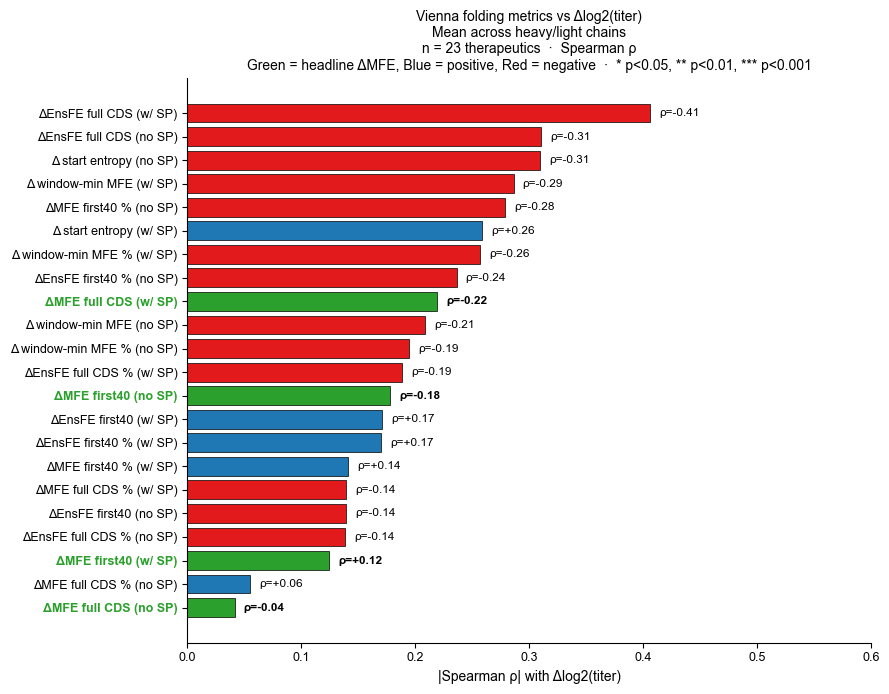


=== Mean grouping (Spearman ρ) ===
 Rank                    Display  Spearman ρ  p_value  n
    1    ΔEnsFE full CDS (w/ SP)   -0.406126 0.054492 23
    2    ΔEnsFE full CDS (no SP)   -0.310277 0.149614 23
    3    Δ start entropy (no SP)   -0.309289 0.150983 23
    4   Δ window-min MFE (w/ SP)   -0.286209 0.185516 23
    5     ΔMFE first40 % (no SP)   -0.278656 0.197904 23
    6    Δ start entropy (w/ SP)    0.258893 0.232932 23
    7 Δ window-min MFE % (w/ SP)   -0.256486 0.237460 23
    8   ΔEnsFE first40 % (no SP)   -0.236166 0.277971 23
    9      ΔMFE full CDS (w/ SP)   -0.219368 0.314560 23
   10   Δ window-min MFE (no SP)   -0.208498 0.339725 23
   11 Δ window-min MFE % (no SP)   -0.194664 0.373427 23
   12  ΔEnsFE full CDS % (w/ SP)   -0.188735 0.388437 23
   13       ΔMFE first40 (no SP)   -0.177866 0.416821 23
   14     ΔEnsFE first40 (w/ SP)    0.170949 0.435457 23
   15   ΔEnsFE first40 % (w/ SP)    0.169960 0.438155 23
   16     ΔMFE first40 % (w/ SP)    0.141304 0.52014

In [70]:
# ============================================================
# Δlog2(titer) vs Vienna RNA folding metrics
# against Δlog2(titer) for: headline 5′ ΔMFEs, ensemble FE,
# sliding-window min MFE, positional entropy, mountain AUC,
# and %-normalized versions.
#
# ============================================================

CORRELATION_METRIC = "spearman"  # "pearson" | "spearman" | "r2"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import re

# -----------------------------
# Input files
# -----------------------------
TITER_FILE  = "master-data.xlsx"
VIENNA_FILE = "vienna-mrna-structure-metrics.xlsx"
VIENNA_SHEET = "Vienna_Metrics"

# -----------------------------
# Settings
# -----------------------------
ID_COL = "Molecule"
PARENT_LABEL = "Patent"
MUT_LABEL    = "Mutated"
TOO_LOW_AS   = np.nan
TITER_PATTERN = r"^Titer\s*mg/L\s*Rep\s*\d+$"

COLOR_POS = "#1f78b4"   # blue
COLOR_NEG = "#e31a1c"   # red
COLOR_HL  = "#2ca02c"   # green — highlight the headline 5′ deltas

# -----------------------------
# Raw delta metrics (from updated Vienna script)
# -----------------------------
RAW_DELTAS = [
    # --- Original MFE deltas ---
    "Delta_first40_MFE_noSP",
    "Delta_first40_MFE_wSP",
    "Delta_full_MFE_noSP",
    "Delta_full_MFE_wSP",

    # --- Ensemble free energy (partition function) ---
    "Delta_first40_ensembleFE_noSP",
    "Delta_first40_ensembleFE_wSP",
    "Delta_full_ensembleFE_noSP",
    "Delta_full_ensembleFE_wSP",

    # --- Sliding-window min MFE along full CDS ---
    "Delta_window_minMFE_noSP",
    "Delta_window_minMFE_wSP",

    # --- Positional entropy over first 30 nt ---
    "Delta_startEntropy_noSP",
    "Delta_startEntropy_wSP",

    # --- Mountain plot AUC over first 40 codons ---
    "Delta_first40_mountainAUC_noSP",
    "Delta_first40_mountainAUC_wSP",
]

# Baselines used only for computing % deltas (not plotted)
PCT_BASELINES = {
    "Delta_first40_MFE_noSP":          "Original_first40_MFE_noSP",
    "Delta_first40_MFE_wSP":           "Original_first40_MFE_wSP",
    "Delta_full_MFE_noSP":             "Original_full_MFE_noSP",
    "Delta_full_MFE_wSP":              "Original_full_MFE_wSP",
    "Delta_first40_ensembleFE_noSP":   "Original_first40_ensembleFE_noSP",
    "Delta_first40_ensembleFE_wSP":    "Original_first40_ensembleFE_wSP",
    "Delta_full_ensembleFE_noSP":      "Original_full_ensembleFE_noSP",
    "Delta_full_ensembleFE_wSP":       "Original_full_ensembleFE_wSP",
    "Delta_window_minMFE_noSP":        "Original_window_minMFE_noSP",
    "Delta_window_minMFE_wSP":         "Original_window_minMFE_wSP",
}

# Friendly display names
DISPLAY_NAMES = {
    # Raw MFE
    "Delta_first40_MFE_noSP":   "ΔMFE first40 (no SP)",
    "Delta_first40_MFE_wSP":    "ΔMFE first40 (w/ SP)",
    "Delta_full_MFE_noSP":      "ΔMFE full CDS (no SP)",
    "Delta_full_MFE_wSP":       "ΔMFE full CDS (w/ SP)",

    # Ensemble FE
    "Delta_first40_ensembleFE_noSP":  "ΔEnsFE first40 (no SP)",
    "Delta_first40_ensembleFE_wSP":   "ΔEnsFE first40 (w/ SP)",
    "Delta_full_ensembleFE_noSP":     "ΔEnsFE full CDS (no SP)",
    "Delta_full_ensembleFE_wSP":      "ΔEnsFE full CDS (w/ SP)",

    # Sliding window min MFE
    "Delta_window_minMFE_noSP":  "Δ window-min MFE (no SP)",
    "Delta_window_minMFE_wSP":   "Δ window-min MFE (w/ SP)",

    # Positional entropy
    "Delta_startEntropy_noSP":   "Δ start entropy (no SP)",
    "Delta_startEntropy_wSP":    "Δ start entropy (w/ SP)",

    # Mountain AUC
    "Delta_first40_mountainAUC_noSP":  "Δ mountain AUC (no SP)",
    "Delta_first40_mountainAUC_wSP":   "Δ mountain AUC (w/ SP)",

    # % versions (added below)
    "Delta_first40_MFE_noSP_pct":         "ΔMFE first40 % (no SP)",
    "Delta_first40_MFE_wSP_pct":          "ΔMFE first40 % (w/ SP)",
    "Delta_full_MFE_noSP_pct":            "ΔMFE full CDS % (no SP)",
    "Delta_full_MFE_wSP_pct":             "ΔMFE full CDS % (w/ SP)",
    "Delta_first40_ensembleFE_noSP_pct":  "ΔEnsFE first40 % (no SP)",
    "Delta_first40_ensembleFE_wSP_pct":   "ΔEnsFE first40 % (w/ SP)",
    "Delta_full_ensembleFE_noSP_pct":     "ΔEnsFE full CDS % (no SP)",
    "Delta_full_ensembleFE_wSP_pct":      "ΔEnsFE full CDS % (w/ SP)",
    "Delta_window_minMFE_noSP_pct":       "Δ window-min MFE % (no SP)",
    "Delta_window_minMFE_wSP_pct":        "Δ window-min MFE % (w/ SP)",
}

# Highlight the four "headline" first-40-codons metrics (MFE only) in green
HIGHLIGHT_METRICS = {
    "Delta_first40_MFE_noSP",
    "Delta_first40_MFE_wSP",
    "Delta_full_MFE_noSP",
    "Delta_full_MFE_wSP",
}

# -----------------------------
# Correlation config
# -----------------------------
CORRELATION_METRIC = CORRELATION_METRIC.lower()
assert CORRELATION_METRIC in {"pearson", "spearman", "r2"}

METRIC_INFO = {
    "pearson":  {"stat_label": "Pearson r",   "abs_label": "|Pearson r|",
                 "value_prefix": "r",  "func": pearsonr},
    "spearman": {"stat_label": "Spearman ρ",  "abs_label": "|Spearman ρ|",
                 "value_prefix": "ρ",  "func": spearmanr},
    "r2":       {"stat_label": "R²",          "abs_label": "R²",
                 "value_prefix": "R²", "func": pearsonr},
}
CFG = METRIC_INFO[CORRELATION_METRIC]

GROUP_TITLE = "Mean across heavy/light chains"

# -----------------------------
# Helpers
# -----------------------------
def clean_numeric(series):
    return pd.to_numeric(
        series.replace({"Too Low": TOO_LOW_AS, "too low": TOO_LOW_AS, "TOO LOW": TOO_LOW_AS,
                        "": np.nan, " ": np.nan, "NA": np.nan, "na": np.nan}),
        errors="coerce",
    )

def rep_num(c):
    m = re.search(r"(\d+)", str(c))
    return int(m.group(1)) if m else 999

def get_chain_group(chain_id):
    s = str(chain_id).strip().lower()
    if s.startswith("heavy"): return "Heavy"
    if s.startswith("light"): return "Light"
    return "Other"

def compute_stat(x, y):
    r, p = CFG["func"](x, y)
    sign = 1 if r >= 0 else -1
    if CORRELATION_METRIC == "r2":
        plot_value, signed_stat = r**2, r**2
    else:
        plot_value, signed_stat = abs(r), r
    return signed_stat, plot_value, sign, p

def fmt_value(signed_stat):
    pfx = CFG["value_prefix"]
    if CORRELATION_METRIC == "r2":
        return f"{pfx}={signed_stat:.2f}"
    return f"{pfx}={signed_stat:+.2f}"

# -----------------------------
# 1) Titer log2FC per therapeutic
# -----------------------------
df = pd.read_excel(TITER_FILE, engine="openpyxl")
df = df.dropna(subset=[ID_COL]).copy()
df[ID_COL] = df[ID_COL].astype(str).str.strip()

parsed = df[ID_COL].str.extract(
    r"^(?P<Base_Molecule>.+?)\s+(?P<Variant>Mutated|Patent)$",
    flags=re.IGNORECASE,
)
df["Base_Molecule"] = parsed["Base_Molecule"].str.strip()
df["Variant"]      = parsed["Variant"].str.capitalize()
df = df.dropna(subset=["Base_Molecule", "Variant"]).copy()

titer_cols = sorted(
    [c for c in df.columns if re.match(TITER_PATTERN, str(c).strip(), re.IGNORECASE)],
    key=rep_num,
)
for c in titer_cols:
    df[c] = clean_numeric(df[c])

df["Titer_row_mean"] = df[titer_cols].mean(axis=1, skipna=True)

titer_long = (df.groupby(["Base_Molecule", "Variant"], dropna=False)
                .agg(Titer_Mean=("Titer_row_mean", "mean"))
                .reset_index())
titer_wide = titer_long.pivot(index="Base_Molecule", columns="Variant",
                              values="Titer_Mean").reset_index()

for v in [PARENT_LABEL, MUT_LABEL]:
    if v not in titer_wide.columns:
        titer_wide[v] = np.nan

pos_vals = titer_wide[[PARENT_LABEL, MUT_LABEL]].values.flatten()
pos_vals = pos_vals[np.isfinite(pos_vals) & (pos_vals > 0)]
eps = 0.01 * np.min(pos_vals) if len(pos_vals) else 1e-6

titer_wide["Titer_log2FC"] = np.log2(
    (titer_wide[MUT_LABEL] + eps) / (titer_wide[PARENT_LABEL] + eps)
)
titer_wide = titer_wide.rename(columns={"Base_Molecule": "Therapeutic"})
titer_wide = titer_wide[["Therapeutic", "Titer_log2FC"]]

# -----------------------------
# 2) Vienna file — load + build %-normalized deltas
# -----------------------------
vienna = pd.read_excel(VIENNA_FILE, sheet_name=VIENNA_SHEET, engine="openpyxl")
vienna["Therapeutic"] = vienna["Therapeutic"].astype(str).str.strip()
vienna["Chain"]       = vienna["Chain"].astype(str).str.strip()
vienna["Chain_Group"] = vienna["Chain"].apply(get_chain_group)
vienna = vienna[vienna["Chain_Group"].isin(["Heavy", "Light"])].copy()

# Coerce all relevant columns to numeric
all_input_cols = set(RAW_DELTAS) | set(PCT_BASELINES.values())
for c in all_input_cols:
    if c in vienna.columns:
        vienna[c] = pd.to_numeric(vienna[c], errors="coerce")

# %-normalized deltas (only for energy-like metrics)
def safe_pct(delta, baseline):
    b = baseline.abs()
    return np.where(b > 1e-9, delta / b * 100.0, np.nan)

PCT_DELTAS = []
for delta_col, baseline_col in PCT_BASELINES.items():
    if delta_col in vienna.columns and baseline_col in vienna.columns:
        pct_col = f"{delta_col}_pct"
        vienna[pct_col] = safe_pct(vienna[delta_col], vienna[baseline_col])
        PCT_DELTAS.append(pct_col)

# All metrics to plot — deltas only (raw + %)
metric_cols = [c for c in RAW_DELTAS + PCT_DELTAS if c in vienna.columns]

print(f"Plotting {len(metric_cols)} metrics:")
for c in metric_cols:
    print(f"   • {DISPLAY_NAMES.get(c, c)}")

# -----------------------------
# 3) Mean-across-chains aggregation only
# -----------------------------
vienna_mean = vienna.groupby("Therapeutic", as_index=False)[metric_cols].mean()

merged = titer_wide.merge(vienna_mean, on="Therapeutic", how="inner")
print(f"Mean n: {len(merged)}")

# -----------------------------
# 4) Correlation table (Mean grouping only)
# -----------------------------
def corr_table(merged, label):
    rows = []
    for c in metric_cols:
        d = merged[["Titer_log2FC", c]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(d) < 3 or d[c].nunique() < 2:
            continue
        signed_stat, plot_value, sign, p = compute_stat(d[c].values, d["Titer_log2FC"].values)
        rows.append({
            "Grouping":    label,
            "Metric":      c,
            "Display":     DISPLAY_NAMES.get(c, c),
            "Stat_signed": signed_stat,
            "Plot_value":  plot_value,
            "Sign":        sign,
            "p_value":     p,
            "n":           len(d),
        })
    return pd.DataFrame(rows)

results_mean = corr_table(merged, "Mean")

# -----------------------------
# 5) Single bar chart (Mean grouping) - display only, no save
# -----------------------------
def plot_grouping(res_df, merged_df, title):
    d = res_df.sort_values("Plot_value", ascending=True).copy()
    n_used = len(merged_df)

    fig, ax = plt.subplots(figsize=(9.0, max(5.0, 0.32 * len(d))))

    highlight_labels = {DISPLAY_NAMES[m] for m in HIGHLIGHT_METRICS
                        if m in DISPLAY_NAMES}

    colors = []
    for metric, sign in zip(d["Metric"], d["Sign"]):
        if metric in HIGHLIGHT_METRICS:
            colors.append(COLOR_HL)
        elif sign < 0:
            colors.append(COLOR_NEG)
        else:
            colors.append(COLOR_POS)

    ax.barh(d["Display"], d["Plot_value"],
            color=colors, edgecolor="black", linewidth=0.5)

    for tick_label in ax.get_yticklabels():
        if tick_label.get_text() in highlight_labels:
            tick_label.set_fontweight("bold")
            tick_label.set_color(COLOR_HL)

    for y, (metric, signed_stat, pv, p) in enumerate(zip(
        d["Metric"], d["Stat_signed"], d["Plot_value"], d["p_value"]
    )):
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        weight = "bold" if metric in HIGHLIGHT_METRICS else "normal"
        ax.text(pv + 0.008, y, f"{fmt_value(signed_stat)}{sig}",
                va="center", fontsize=8.5, fontweight=weight)

    ax.set_xlabel(f"{CFG['abs_label']} with Δlog2(titer)", fontsize=10)
    legend_line = "Green = headline ΔMFE, Blue = positive, Red = negative"
    ax.set_title(
        f"Vienna folding metrics vs Δlog2(titer)\n{title}\n"
        f"n = {n_used} therapeutics  ·  {CFG['stat_label']}\n"
        f"{legend_line}  ·  * p<0.05, ** p<0.01, *** p<0.001",
        fontsize=10,
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, max(0.6, d["Plot_value"].max() * 1.30))
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=9)

    plt.tight_layout()
    plt.show()

plot_grouping(res_df=results_mean, merged_df=merged, title=GROUP_TITLE)

# -----------------------------
# 6) Console preview: full ranking (Mean grouping)
# -----------------------------
ranked = results_mean.sort_values("Plot_value", ascending=False).reset_index(drop=True)
ranked["Rank"] = ranked.index + 1
print(f"\n=== Mean grouping ({CFG['stat_label']}) ===")
preview = ranked[["Rank", "Display", "Stat_signed", "p_value", "n"]].rename(
    columns={"Stat_signed": CFG["stat_label"]}
)
print(preview.to_string(index=False))


Figure 5c

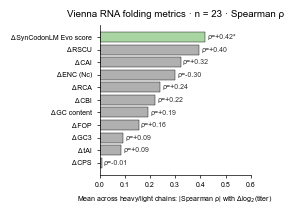

Saved: Figure_Vienna_vs_Titer_SpearmanRho_Mean.svg


In [71]:
# ============================================================
# Mean across heavy/light chains — Vienna structural metrics + Evo
# Nature-submission SVG styling to match the waterfall figure.
# Excludes all "w/ SP" metrics. Adds SynCodonLM Evo (ρ = 0.42).
# Only the Evo bar is green; everything else is gray.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------
# SVG / figure styling (matches waterfall)
# -----------------------------
MM_TO_INCH = 1 / 25.4

FIG_WIDTH_MM  = 70
ROW_HEIGHT_MM = 3.2
BASE_PAD_MM   = 22

FONT_NAME       = "Arial"
TITLE_FONTSIZE  = 7
AXIS_FONTSIZE   = 5
TICK_FONTSIZE   = 5
TEXT_FONTSIZE   = 5

# Colors
COLOR_CLASSICAL = "#b0b0b0"
COLOR_EVO       = "#a8d5a2"

# Keep SVG text editable
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.family"]  = FONT_NAME
plt.rcParams["pdf.fonttype"] = 42

# -----------------------------
# Local, self-contained stat config
# (renamed CFG -> PLOT_CFG on purpose: this notebook reuses the name
#  "CFG" for unrelated things elsewhere in the session — e.g. fine-tuning
#  configs or the other figure's setup cell — which was clobbering this
#  dict and caused KeyError: 'file_suffix'. Rebuilding it locally here
#  avoids that clash regardless of what ran before this cell.)
# -----------------------------
_METRIC_INFO = {
    "pearson":  {"stat_label": "Pearson r",  "abs_label": "|Pearson r|", "value_prefix": "r",  "file_suffix": "PearsonR"},
    "spearman": {"stat_label": "Spearman ρ", "abs_label": "|Spearman ρ|", "value_prefix": "ρ", "file_suffix": "SpearmanRho"},
    "r2":       {"stat_label": "R²",         "abs_label": "R²",          "value_prefix": "R²", "file_suffix": "R2"},
}
PLOT_CFG = _METRIC_INFO[CORRELATION_METRIC.lower()]
CFG = PLOT_CFG  # keep name CFG available for the f-strings below, now guaranteed correct

OUT_FIG = f"Figure_Vienna_vs_Titer_{CFG['file_suffix']}_Mean.svg"

# -----------------------------
# Evo entry (SynCodonLM)
# -----------------------------
EVO_METRIC_NAME = "Evo_SynCodonLM"
EVO_DISPLAY     = "SynCodonLM Evo score"

# Spearman rho
EVO_RHO = 0.42
EVO_P   = np.nan   # set to your exact Spearman p if you have it

# -----------------------------
# Data — filter out wSP metrics
# -----------------------------
res_df    = results_by_group["Mean"].copy()
merged_df = merged_by_group["Mean"]

n_used = len(merged_df)

# Drop anything containing wSP
res_df = res_df[
    ~res_df["Metric"].str.contains("wSP", case=False, na=False)
].copy()

# Drop any pre-existing Evo/SynCodonLM row(s) carried over from
# results_by_group["Mean"] — we add our own single Evo row below
# (with the hardcoded EVO_RHO), so keeping the upstream one too
# would duplicate the "SynCodonLM Evo score" bar.
res_df = res_df[
    ~res_df["Metric"].str.contains("evo", case=False, na=False)
    & ~res_df["Display"].str.contains("evo", case=False, na=False)
].copy()

# Derive Evo p-value from rho and n if an exact value wasn't provided
if not np.isfinite(EVO_P) and np.isfinite(EVO_RHO) and n_used > 2 and abs(EVO_RHO) < 1:
    t_stat = EVO_RHO * np.sqrt((n_used - 2) / (1 - EVO_RHO**2))
    EVO_P = 2 * stats.t.sf(abs(t_stat), df=n_used - 2)

# Build Evo row
if CORRELATION_METRIC == "r2":
    evo_plot   = EVO_RHO ** 2
    evo_signed = EVO_RHO ** 2
else:
    evo_plot   = abs(EVO_RHO)
    evo_signed = EVO_RHO

evo_row = pd.DataFrame([{
    "Grouping":    "Mean",
    "Metric":      EVO_METRIC_NAME,
    "Display":     EVO_DISPLAY,
    "Stat_signed": evo_signed,
    "Plot_value":  evo_plot,
    "Sign":        1 if EVO_RHO >= 0 else -1,
    "p_value":     EVO_P,
    "n":           n_used,
}])

d = pd.concat([res_df, evo_row], ignore_index=True)
d = d.sort_values("Plot_value", ascending=True).reset_index(drop=True)

# Clean labels
d["Display"] = d["Display"].str.replace(
    r"\s*\(no SP\)",
    "",
    regex=True
)

# -----------------------------
# Formatting helpers
# -----------------------------
def fmt_value(signed_stat):

    if CORRELATION_METRIC == "r2":
        return f"R²={signed_stat:.2f}"

    return f"ρ={signed_stat:+.2f}"

def sig_stars(p):
    if not np.isfinite(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

# -----------------------------
# Figure
# -----------------------------
fig_height_mm = BASE_PAD_MM + ROW_HEIGHT_MM * len(d)

FIGSIZE = (
    FIG_WIDTH_MM * MM_TO_INCH,
    fig_height_mm * MM_TO_INCH
)

fig, ax = plt.subplots(figsize=FIGSIZE)

colors = [
    COLOR_EVO if metric == EVO_METRIC_NAME
    else COLOR_CLASSICAL
    for metric in d["Metric"]
]


def add_delta(name):
    name = str(name).lstrip()
    if name.startswith("Δ"):
        # already has a delta — ensure a single space follows it
        return "Δ " + name[1:].lstrip()
    return "Δ " + name

delta_labels = [add_delta(name) for name in d["Display"]]

ax.barh(
    delta_labels,
    d["Plot_value"],
    color=colors,
    edgecolor="black",
    linewidth=0.3,
)

# -----------------------------
# Bar annotations
# -----------------------------
for y, (signed_stat, pv, p) in enumerate(
    zip(
        d["Stat_signed"],
        d["Plot_value"],
        d["p_value"],
    )
):

    ax.text(
        pv + 0.008,
        y,
        f"{fmt_value(signed_stat)}{sig_stars(p)}",
        va="center",
        fontsize=TEXT_FONTSIZE,
        fontname=FONT_NAME,
        color="#333333",
    )

# -----------------------------
# Labels / title
# -----------------------------
ax.set_xlabel(
    "Mean across heavy/light chains: |Spearman ρ| with Δlog$_2$(titer)",
    fontsize=AXIS_FONTSIZE,
    fontname=FONT_NAME,
)

ax.set_title(
    f"Vienna RNA folding metrics · n = {n_used} · Spearman ρ",
    fontsize=TITLE_FONTSIZE,
    fontname=FONT_NAME,
)

# -----------------------------
# Axes styling
# -----------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.5)
ax.spines["bottom"].set_linewidth(0.5)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=TICK_FONTSIZE,
    width=0.5,
    length=2,
)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname(FONT_NAME)
    label.set_fontsize(TICK_FONTSIZE)

ax.set_xlim(
    0,
    max(
        0.6,
        d["Plot_value"].max() * 1.35
    )
)

plt.tight_layout()

fig.savefig(
    OUT_FIG,
    format="svg",
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {OUT_FIG}")


Supplementary Figure 9

Total codons: 16,499
Overall edit rate: 9.8%


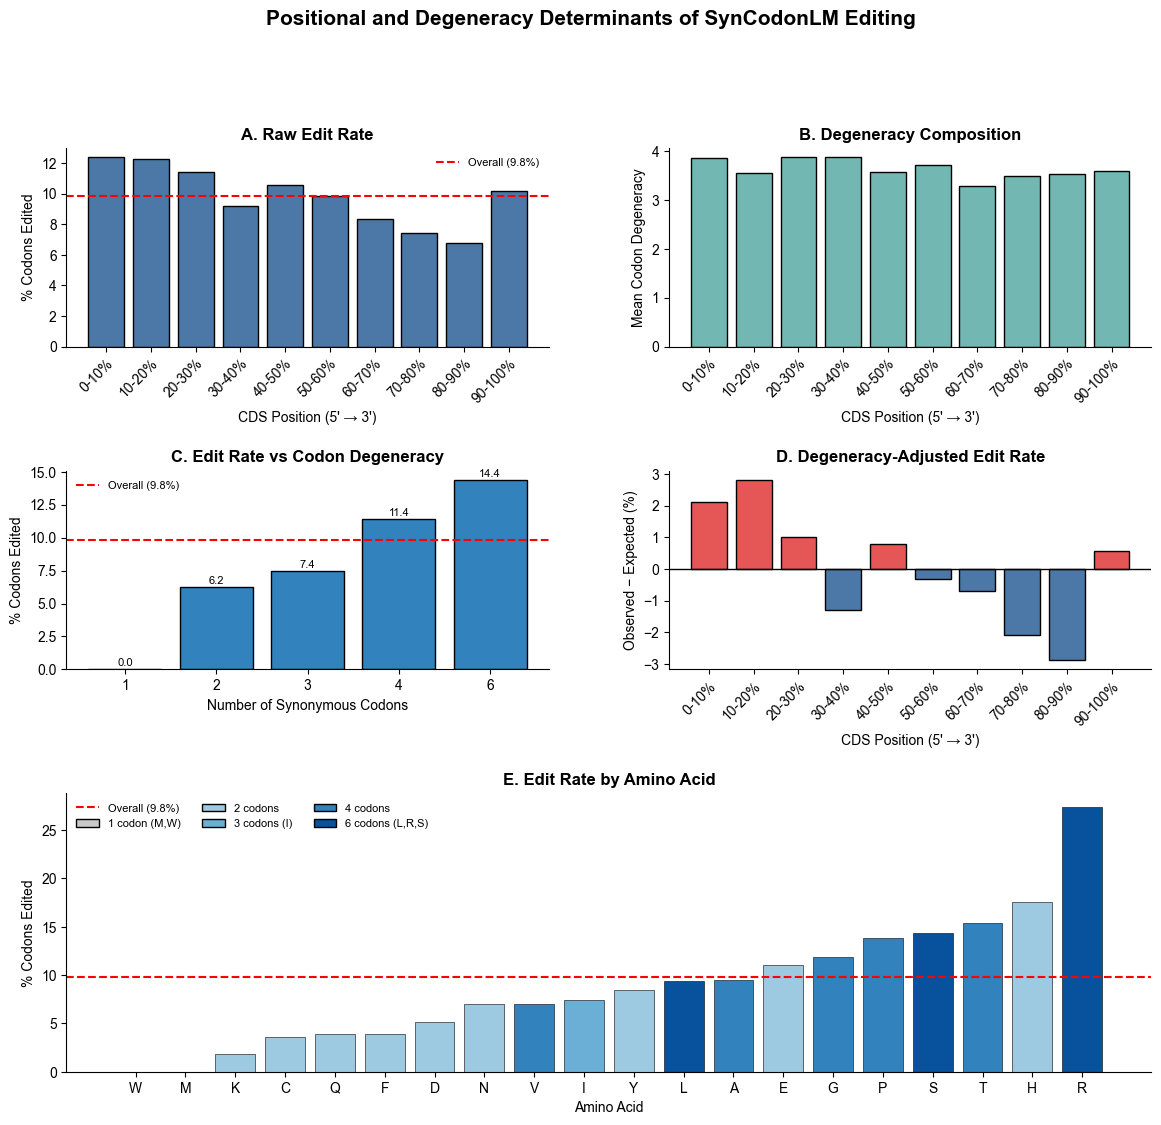

In [72]:
# ============================================================================
# POSITIONAL AND DEGENERACY DETERMINANTS OF SynCodonLM EDITING
#
#   A. Raw edit rate along the CDS (5' -> 3', 10 bins)
#   B. Mean codon degeneracy in each CDS bin
#   C. Edit rate vs codon degeneracy (# synonymous codons)
#   D. Degeneracy-adjusted edit rate (observed - expected per bin)
#   E. Edit rate by amino acid, colored by degeneracy
# ============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# INPUT
# ---------------------------------------------------------------------------
XL_FILE = "patented+mutated-sequences-with-evo-scores.xlsx"
SHEET   = "Scored_Sequences"

PATCOL  = "Original_DNA"
OPTCOL  = "Optimized_DNA"

N_BINS  = 10        # number of positional bins along the CDS
MIN_COD = 20        # skip sequences shorter than this many codons

# ---------------------------------------------------------------------------
# GENETIC CODE
# ---------------------------------------------------------------------------
CODON = {
    'TTT':'F','TTC':'F','TTA':'L','TTG':'L','CTT':'L','CTC':'L','CTA':'L','CTG':'L',
    'ATT':'I','ATC':'I','ATA':'I','ATG':'M',
    'GTT':'V','GTC':'V','GTA':'V','GTG':'V',
    'TCT':'S','TCC':'S','TCA':'S','TCG':'S',
    'CCT':'P','CCC':'P','CCA':'P','CCG':'P',
    'ACT':'T','ACC':'T','ACA':'T','ACG':'T',
    'GCT':'A','GCC':'A','GCA':'A','GCG':'A',
    'TAT':'Y','TAC':'Y',
    'CAT':'H','CAC':'H',
    'CAA':'Q','CAG':'Q',
    'AAT':'N','AAC':'N',
    'AAA':'K','AAG':'K',
    'GAT':'D','GAC':'D',
    'GAA':'E','GAG':'E',
    'TGT':'C','TGC':'C',
    'TGG':'W',
    'CGT':'R','CGC':'R','CGA':'R','CGG':'R',
    'AGA':'R','AGG':'R',
    'AGT':'S','AGC':'S',
    'GGT':'G','GGC':'G','GGA':'G','GGG':'G',
    'TAA':'*','TAG':'*','TGA':'*'
}

# degeneracy = number of synonymous codons per amino acid
DEGEN = {}
for codon, aa in CODON.items():
    DEGEN[aa] = DEGEN.get(aa, 0) + 1

# ---------------------------------------------------------------------------
# HELPERS
# ---------------------------------------------------------------------------
def clean(seq):
    if not isinstance(seq, str):
        return ""
    seq = "".join(seq.split()).upper().replace("U", "T")
    return "".join(x for x in seq if x in "ACGT")

# ---------------------------------------------------------------------------
# LOAD DATA
# ---------------------------------------------------------------------------
df = pd.read_excel(XL_FILE, sheet_name=SHEET, engine="openpyxl")
df = df.dropna(subset=[PATCOL, OPTCOL])

# ---------------------------------------------------------------------------
# BUILD PER-CODON TABLE  (now also records positional bin)
# ---------------------------------------------------------------------------
records = []

for _, row in df.iterrows():

    pat = clean(row[PATCOL])
    opt = clean(row[OPTCOL])

    n = min(len(pat), len(opt))
    n -= n % 3
    ncod = n // 3

    if ncod < MIN_COD:
        continue

    for i in range(ncod):

        c1 = pat[3*i:3*i+3]
        c2 = opt[3*i:3*i+3]

        aa = CODON.get(c1, "X")
        if aa in ["*", "X"]:
            continue

        # fractional position along the CDS -> bin 0 .. N_BINS-1
        frac = i / ncod
        pos_bin = min(int(frac * N_BINS), N_BINS - 1)

        records.append({
            "aa":         aa,
            "degeneracy": DEGEN[aa],
            "edited":     int(c1 != c2),
            "pos_bin":    pos_bin,
        })

d = pd.DataFrame(records)

overall = d["edited"].mean() * 100
print(f"Total codons: {len(d):,}")
print(f"Overall edit rate: {overall:.1f}%")

# ---------------------------------------------------------------------------
# SUMMARIES
# ---------------------------------------------------------------------------
# A. raw edit rate per positional bin
raw_rate = (
    d.groupby("pos_bin")["edited"].mean().mul(100).reindex(range(N_BINS))
)

# B. mean codon degeneracy per positional bin
deg_comp = (
    d.groupby("pos_bin")["degeneracy"].mean().reindex(range(N_BINS))
)

# C. edit rate by number of synonymous codons
deg_rate = d.groupby("degeneracy")["edited"].mean().mul(100)

# D. degeneracy-adjusted edit rate = observed - expected per bin
#    expected rate for a codon = the edit rate for its degeneracy class
expected_per_codon = d["degeneracy"].map(deg_rate / 100)
d["expected"] = expected_per_codon
expected_bin = d.groupby("pos_bin")["expected"].mean().mul(100).reindex(range(N_BINS))
adj_rate = raw_rate - expected_bin

# E. edit rate by amino acid + its degeneracy
aa_rate = d.groupby("aa")["edited"].mean().mul(100)
aa_deg  = d.groupby("aa")["degeneracy"].first()

# bin labels for the x-axis (0-10%, 10-20%, ...)
labels = [f"{i*10}-{(i+1)*10}%" for i in range(N_BINS)]

# color map keyed by degeneracy (used in panel E)
cmap = {
    1: "#c9c9c9",
    2: "#9ecae1",
    3: "#6baed6",
    4: "#3182bd",
    6: "#08519c",
}

# ============================================================================
# COMBINED FIGURE
# ============================================================================
fig = plt.figure(figsize=(14, 12))

gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[1, 1, 1.4],
    hspace=0.55,
    wspace=0.25,
)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])
axE = fig.add_subplot(gs[2, :])

# ----------------------------------------------------------------------------
# A. RAW EDIT RATE
# ----------------------------------------------------------------------------
axA.bar(range(N_BINS), raw_rate.values, color="#4C78A8", edgecolor="black")
axA.axhline(overall, color="red", linestyle="--", linewidth=1.5,
            label=f"Overall ({overall:.1f}%)")
axA.set_xticks(range(N_BINS))
axA.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor")
axA.set_ylabel("% Codons Edited")
axA.set_xlabel("CDS Position (5' \u2192 3')")
axA.set_title("A. Raw Edit Rate", fontweight="bold")
axA.legend(frameon=False, fontsize=8)

# ----------------------------------------------------------------------------
# B. DEGENERACY COMPOSITION
# ----------------------------------------------------------------------------
axB.bar(range(N_BINS), deg_comp.values, color="#72B7B2", edgecolor="black")
axB.set_xticks(range(N_BINS))
axB.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor")
axB.set_ylabel("Mean Codon Degeneracy")
axB.set_xlabel("CDS Position (5' \u2192 3')")
axB.set_title("B. Degeneracy Composition", fontweight="bold")

# ----------------------------------------------------------------------------
# C. EDIT RATE VS CODON DEGENERACY
# ----------------------------------------------------------------------------
axC.bar(deg_rate.index.astype(str), deg_rate.values,
        color="#3182bd", edgecolor="black")
axC.axhline(overall, color="red", linestyle="--", linewidth=1.5,
            label=f"Overall ({overall:.1f}%)")
axC.set_xlabel("Number of Synonymous Codons")
axC.set_ylabel("% Codons Edited")
axC.set_title("C. Edit Rate vs Codon Degeneracy", fontweight="bold")
for i, y in enumerate(deg_rate.values):
    axC.text(i, y + 0.25, f"{y:.1f}", ha="center", fontsize=8)
axC.legend(frameon=False, fontsize=8)

# ----------------------------------------------------------------------------
# D. DEGENERACY-ADJUSTED EDIT RATE
# ----------------------------------------------------------------------------
colors = ["#E45756" if x > 0 else "#4C78A8" for x in adj_rate.values]
axD.bar(range(N_BINS), adj_rate.values, color=colors, edgecolor="black")
axD.axhline(0, color="black", linewidth=1)
axD.set_xticks(range(N_BINS))
axD.set_xticklabels(labels, rotation=45, ha="right", rotation_mode="anchor")
axD.set_ylabel("Observed \u2212 Expected (%)")
axD.set_xlabel("CDS Position (5' \u2192 3')")
axD.set_title("D. Degeneracy-Adjusted Edit Rate", fontweight="bold")

# ----------------------------------------------------------------------------
# E. EDIT RATE BY AMINO ACID
# ----------------------------------------------------------------------------
order = aa_rate.sort_values().index
axE.bar(range(len(order)), aa_rate[order].values,
        color=[cmap[aa_deg[a]] for a in order],
        edgecolor="black", linewidth=0.4)
axE.axhline(overall, color="red", linestyle="--", linewidth=1.5)
axE.set_xticks(range(len(order)))
axE.set_xticklabels(order)
axE.set_xlabel("Amino Acid")
axE.set_ylabel("% Codons Edited")
axE.set_title("E. Edit Rate by Amino Acid", fontweight="bold")

legend_handles = [
    Line2D([0], [0], color="red", linestyle="--", lw=1.5,
           label=f"Overall ({overall:.1f}%)"),
    Patch(facecolor=cmap[1], edgecolor="black", label="1 codon (M,W)"),
    Patch(facecolor=cmap[2], edgecolor="black", label="2 codons"),
    Patch(facecolor=cmap[3], edgecolor="black", label="3 codons (I)"),
    Patch(facecolor=cmap[4], edgecolor="black", label="4 codons"),
    Patch(facecolor=cmap[6], edgecolor="black", label="6 codons (L,R,S)"),
]
axE.legend(handles=legend_handles, fontsize=8, frameon=False,
           ncol=3, loc="upper left")

# ----------------------------------------------------------------------------
# CLEANUP
# ----------------------------------------------------------------------------
for ax in [axA, axB, axC, axD, axE]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle("Positional and Degeneracy Determinants of SynCodonLM Editing",
             fontsize=15, fontweight="bold", y=0.995)

fig.savefig("Figure_Combined_ABCDE.png", dpi=300, bbox_inches="tight")
plt.show()


Supplementary Figure 10

Per-residue table: 15,315 residues, 45 chains (edit rate 9.8%)  SS: SASA-fallback=45 | skipped 2

=== Degeneracy-controlled context tests (FDR across panel) ===
                       label    OR    lo    hi     p     q   sig
            pLDDT confidence 1.069 1.008 1.135 0.027 0.102 False
         Sheet N-cap (start) 0.804 0.704 0.917 0.001 0.009  True
Pre-helix (1-2 before start) 0.854 0.590 1.235 0.401 0.547 False
           Sheet C-cap (end) 1.034 0.942 1.134 0.485 0.607 False
         Helix N-cap (start) 1.034 0.882 1.211 0.681 0.681 False
Pre-sheet (1-2 before start) 1.120 0.950 1.319 0.177 0.384 False
           Helix C-cap (end) 1.154 0.983 1.354 0.081 0.242 False
          Buried (<0.20 ASA) 0.940 0.845 1.045 0.250 0.404 False
          Exposure (rel_asa) 1.056 1.009 1.106 0.020 0.099 False
             Position 5'->3' 0.864 0.796 0.938 0.001 0.008  True
           Ramachandran beta 0.926 0.822 1.043 0.205 0.384 False
          Ramachandran alpha 1.043 0.896 1.215 0.584 0.625 

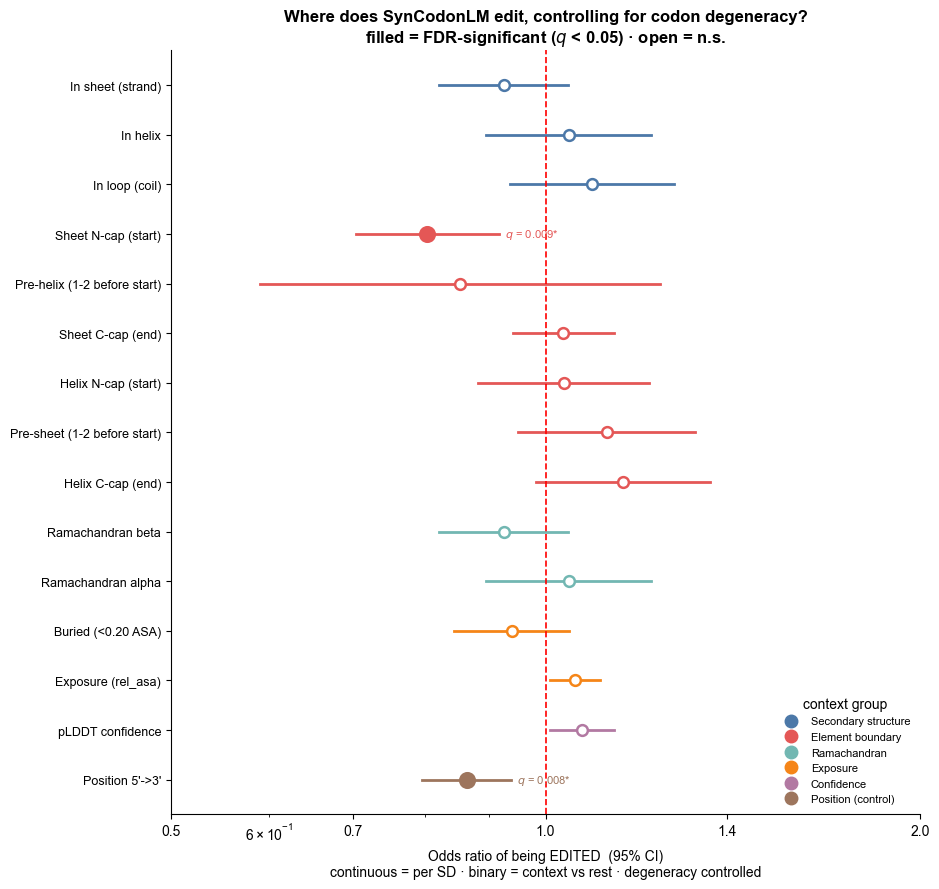


Saved: ss_boundary_perresidue.csv and Figure_SS_Boundary_Significance.pdf

Read it like this:  OR>1 (right of red line) = edited MORE in that context;
OR<1 = edited LESS.  Only FILLED dots survive degeneracy control at FDR<0.05.


In [73]:
# ============================================================================
import os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
warnings.filterwarnings("ignore")

# ---- file paths & tunable settings ---------------------------------------
XL      = "patented+mutated-sequences-with-evo-scores.xlsx"
SHEET   = "Scored_Sequences"
PATCOL, OPTCOL = "Original_DNA", "Optimized_DNA"
STRUCT_DIR    = "structures"
STRUCT_SUFFIX = "_translation-h04na.pdb"
OUT_CSV = "ss_boundary_perresidue.csv"
OUT_FIG = "Figure_SS_Boundary_Significance.pdf"

CAP_N   = 2       # residues counted as "at the start" (N-cap) of an element
CAP_C   = 2       # residues counted as "at the end"   (C-cap) of an element
FLANK   = 2       # residues immediately BEFORE an element start (pre-element)
BURIED  = 0.20    # rel_asa threshold for calling a residue "buried"

# ---- genetic code + codon degeneracy per amino acid ----------------------
CODON={ 'TTT':'F','TTC':'F','TTA':'L','TTG':'L','CTT':'L','CTC':'L','CTA':'L','CTG':'L',
 'ATT':'I','ATC':'I','ATA':'I','ATG':'M','GTT':'V','GTC':'V','GTA':'V','GTG':'V',
 'TCT':'S','TCC':'S','TCA':'S','TCG':'S','CCT':'P','CCC':'P','CCA':'P','CCG':'P',
 'ACT':'T','ACC':'T','ACA':'T','ACG':'T','GCT':'A','GCC':'A','GCA':'A','GCG':'A',
 'TAT':'Y','TAC':'Y','TAA':'*','TAG':'*','CAT':'H','CAC':'H','CAA':'Q','CAG':'Q',
 'AAT':'N','AAC':'N','AAA':'K','AAG':'K','GAT':'D','GAC':'D','GAA':'E','GAG':'E',
 'TGT':'C','TGC':'C','TGA':'*','TGG':'W','CGT':'R','CGC':'R','CGA':'R','CGG':'R',
 'AGT':'S','AGC':'S','AGA':'R','AGG':'R','GGT':'G','GGC':'G','GGA':'G','GGG':'G'}
DEGEN={}
for c,a in CODON.items(): DEGEN[a]=DEGEN.get(a,0)+1   # e.g. L,R,S -> 6 ; M,W -> 1

T2O={'ALA':'A','ARG':'R','ASN':'N','ASP':'D','CYS':'C','GLN':'Q','GLU':'E','GLY':'G',
 'HIS':'H','ILE':'I','LEU':'L','LYS':'K','MET':'M','PHE':'F','PRO':'P','SER':'S',
 'THR':'T','TRP':'W','TYR':'Y','VAL':'V','MSE':'M'}
MAXASA={'A':129,'R':274,'N':195,'D':193,'C':167,'Q':225,'E':223,'G':104,'H':224,
 'I':197,'L':201,'K':236,'M':224,'F':240,'P':159,'S':155,'T':172,'W':285,'Y':263,'V':174,'X':200}

# ---- small helper functions ----------------------------------------------
def clean(s):
    """Uppercase, strip whitespace, RNA->DNA, keep only ACGT."""
    if not isinstance(s,str): return ""
    s="".join(s.split()).upper().replace("U","T")
    return "".join(c if c in "ACGT" else "" for c in s)

def translate(d):
    """DNA -> protein (X for unknown codons)."""
    d=d[:len(d)-len(d)%3]
    return "".join(CODON.get(d[i:i+3],'X') for i in range(0,len(d),3))

def cg(c):
    """Classify a chain label as Heavy / Light / Other."""
    s=str(c).strip().lower()
    return "Heavy" if s.startswith("heavy") else "Light" if s.startswith("light") else "Other"

def ss3_of(s):
    """Collapse 8-state DSSP into 3 states: Helix / Strand / Coil."""
    return "Helix" if s in "HGI" else "Strand" if s in "EB" else "Coil"

def rama_of(phi,psi):
    """Assign a residue to an alpha or beta Ramachandran basin from phi/psi."""
    if phi is None or psi is None or np.isnan(phi) or np.isnan(psi): return "NA"
    if -160<=phi<=-40 and -70<=psi<=-10: return "alpha"
    if -180<=phi<=-40 and (90<=psi<=180 or -180<=psi<=-160): return "beta"
    return "other"

# ---- per-residue pLDDT (from the B-factor column of the PDB) --------------
def _plddt(path,n):
    res={}; order=[]; c0=None
    for line in open(path):
        if not line.startswith(("ATOM","HETATM")): continue
        ch=line[21]
        if c0 is None: c0=ch
        if ch!=c0: continue
        rid=line[22:27].strip()
        if rid not in res: res[rid]=[]; order.append(rid)
        try: res[rid].append(float(line[60:66]))
        except: pass
    return np.array([np.mean(res[r]) if res[r] else np.nan for r in order])

# ---- structural feature extraction (DSSP first, SASA/geometry fallback) ---
def features(path):
    from Bio.PDB import PDBParser
    # Preferred path: DSSP gives SS, relative ASA, and phi/psi directly.
    try:
        from Bio.PDB.DSSP import DSSP
        m=PDBParser(QUIET=True).get_structure("x",path)[0]
        d=DSSP(m,path)
        seq,ss8,rasa,phi,psi=[],[],[],[],[]
        for k in d.keys():
            r=d[k]
            seq.append(r[1] if r[1] not in (None,"X") else "X")
            ss8.append(r[2] if r[2] not in (None," ") else "-")
            rasa.append(r[3] if isinstance(r[3],(int,float)) else np.nan)
            phi.append(r[4] if isinstance(r[4],(int,float)) else np.nan)
            psi.append(r[5] if isinstance(r[5],(int,float)) else np.nan)
        return "".join(seq),ss8,np.array(rasa),np.array(phi),np.array(psi),_plddt(path,len(seq)),"DSSP"
    except Exception:
        pass
    # Fallback: compute ASA (Shrake-Rupley) and phi/psi ourselves; SS from geometry.
    from Bio.PDB.SASA import ShrakeRupley
    from Bio.PDB.Polypeptide import PPBuilder
    m=PDBParser(QUIET=True).get_structure("x",path)[0]
    ch=[c for c in m][0]; ShrakeRupley().compute(m,level="R")
    pp={}
    for poly in PPBuilder().build_peptides(ch):
        for res,(ph,ps) in zip(poly,poly.get_phi_psi_list()):
            pp[res.get_id()]=(ph,ps)
    seq,ss8,rasa,phi,psi=[],[],[],[],[]
    for res in ch:
        aa=T2O.get(res.get_resname(),"X"); seq.append(aa)
        sa=getattr(res,"sasa",np.nan)
        rasa.append(min(sa/MAXASA.get(aa,200),1.0) if sa==sa else np.nan)
        ph,ps=pp.get(res.get_id(),(None,None))
        ph=np.degrees(ph) if ph is not None else np.nan
        ps=np.degrees(ps) if ps is not None else np.nan
        phi.append(ph); psi.append(ps)
        ss8.append("H" if (-160<=ph<=-40 and -70<=ps<=-10) else
                   "E" if (-180<=ph<=-40 and (90<=ps<=180 or -180<=ps<=-160)) else "-")
    return "".join(seq),ss8,np.array(rasa),np.array(phi),np.array(psi),_plddt(path,len(seq)),"SASA-fallback"

def offset(protein,struct_seq):
    """Find where the translated CDS best lines up with the modeled sequence."""
    i=struct_seq.find(protein)
    if i>=0: return i
    best,bo=-1,0
    for o in range(max(1,len(struct_seq)-len(protein)+1)):
        seg=struct_seq[o:o+len(protein)]
        if len(seg)<len(protein): break
        s=np.mean([a==b for a,b in zip(protein,seg)])
        if s>best: best,bo=s,o
    return bo

def boundary_flags(ss3_list):
    """Mark pre- / N-cap / C-cap residues for each helix and strand segment."""
    n=len(ss3_list)
    out={k:np.zeros(n,dtype=int) for k in
         ["pre_helix","helix_ncap","helix_ccap","pre_sheet","sheet_ncap","sheet_ccap"]}
    i=0
    while i<n:
        s=ss3_list[i]
        if s in ("Helix","Strand"):
            j=i
            while j<n and ss3_list[j]==s: j+=1   # walk to end of this segment
            L=j-i
            pre = "pre_helix" if s=="Helix" else "pre_sheet"
            nc  = "helix_ncap" if s=="Helix" else "sheet_ncap"
            cc  = "helix_ccap" if s=="Helix" else "sheet_ccap"
            for f in range(1,FLANK+1):                       # coil residues just before start
                if i-f>=0 and ss3_list[i-f]=="Coil": out[pre][i-f]=1
            for c in range(min(CAP_N,L)): out[nc][i+c]=1     # first CAP_N residues (start)
            for c in range(min(CAP_C,L)): out[cc][j-1-c]=1   # last CAP_C residues (end)
            i=j
        else:
            i+=1
    return out

# ============================================================================
# STEP 1 — Build the per-residue table (one row per codon/residue)
# ============================================================================
df=pd.read_excel(XL,sheet_name=SHEET,engine="openpyxl").dropna(subset=[PATCOL,OPTCOL])
df["grp"]=df["Chain"].apply(cg); df=df[df["grp"].isin(["Heavy","Light"])]
rows=[]; methods={}; skipped=0
for _,r in df.iterrows():
    ther,chain=str(r["Therapeutic"]).strip(),str(r["Chain"]).strip()
    pat,opt=clean(r[PATCOL]),clean(r[OPTCOL])
    n=min(len(pat),len(opt)); n-=n%3; ncod=n//3
    if ncod<20: continue                                     # skip very short chains
    # edited[k] = 1 if the parental and optimized codon differ at position k
    changed=np.array([1 if pat[3*k:3*k+3]!=opt[3*k:3*k+3] else 0 for k in range(ncod)])
    protein=translate(pat).rstrip("*")[:ncod]
    pdb=os.path.join(STRUCT_DIR,f"{ther}_{chain}{STRUCT_SUFFIX}".replace(" ","_"))
    if not os.path.exists(pdb): skipped+=1; continue
    try: seq,ss8,rasa,phi,psi,plddt,method=features(pdb)
    except Exception: skipped+=1; continue
    methods[method]=methods.get(method,0)+1
    off=offset(protein,seq); L=len(protein)
    # secondary structure in codon order (aligned to the CDS)
    ss3_codon=[ss3_of(ss8[off+k]) if 0<=off+k<len(ss8) else "Coil" for k in range(L)]
    bnd=boundary_flags(ss3_codon)
    for k in range(L):
        j=off+k
        if not (0<=j<len(seq)): continue
        aa=protein[k]
        rows.append(dict(chain_id=f"{ther}|{chain}",edited=int(changed[k]),aa=aa,
            degeneracy=DEGEN.get(aa,np.nan),
            ss3=ss3_codon[k],
            in_helix=int(ss3_codon[k]=="Helix"),
            in_sheet=int(ss3_codon[k]=="Strand"),
            in_loop=int(ss3_codon[k]=="Coil"),
            rama=rama_of(phi[j] if j<len(phi) else np.nan, psi[j] if j<len(psi) else np.nan),
            rel_asa=rasa[j] if j<len(rasa) else np.nan,
            plddt=plddt[j] if j<len(plddt) else np.nan,
            norm_pos=k/max(1,L-1),
            **{key:bnd[key][k] for key in bnd}))
d=pd.DataFrame(rows)
d["buried"]=(d["rel_asa"]<BURIED).astype(float)
d["is_alpha"]=(d["rama"]=="alpha").astype(int)
d["is_beta"] =(d["rama"]=="beta").astype(int)
d.to_csv(OUT_CSV,index=False)
print(f"Per-residue table: {len(d):,} residues, {d.chain_id.nunique()} chains "
      f"(edit rate {d.edited.mean()*100:.1f}%)  SS:",
      ", ".join(f"{k}={v}" for k,v in methods.items()), "| skipped", skipped)

# ============================================================================
# STEP 2 — One degeneracy-controlled logistic regression PER context feature
# ============================================================================
def fit_feature(col, kind):
    """Fit  edited ~ feature + degeneracy(std)  with chain-clustered errors.
       kind='binary' -> odds ratio for the context vs. all other residues.
       kind='cont'   -> odds ratio per 1 SD of the (standardized) feature."""
    sub=d.dropna(subset=[col,"degeneracy"]).copy()
    if kind=="binary" and sub[col].sum()<20:      # too few positives to fit reliably
        return None
    # standardize degeneracy so its coefficient is comparable across fits
    sub["deg_z"]=(sub["degeneracy"]-sub["degeneracy"].mean())/sub["degeneracy"].std(ddof=0)
    if kind=="cont":
        s=sub[col].std(ddof=0)
        sub["feat"]=(sub[col]-sub[col].mean())/(s if s>0 else 1)   # z-score
    else:
        sub["feat"]=sub[col].astype(float)                         # 0/1 indicator
    try:
        m=smf.logit("edited ~ feat + deg_z", sub).fit(
            disp=0, cov_type="cluster", cov_kwds={"groups":sub["chain_id"]})
        return dict(OR=np.exp(m.params["feat"]), p=m.pvalues["feat"],
                    lo=np.exp(m.conf_int().loc["feat",0]),
                    hi=np.exp(m.conf_int().loc["feat",1]),
                    n_pos=int(sub[col].sum()) if kind=="binary" else len(sub))
    except Exception:
        return None

# (label shown on plot, column name, feature type, context group)
PANEL=[
 ("In helix",            "in_helix",   "binary","Secondary structure"),
 ("In sheet (strand)",   "in_sheet",   "binary","Secondary structure"),
 ("In loop (coil)",      "in_loop",    "binary","Secondary structure"),
 ("Pre-helix (1-2 before start)", "pre_helix",  "binary","Element boundary"),
 ("Helix N-cap (start)", "helix_ncap", "binary","Element boundary"),
 ("Helix C-cap (end)",   "helix_ccap", "binary","Element boundary"),
 ("Pre-sheet (1-2 before start)", "pre_sheet",  "binary","Element boundary"),
 ("Sheet N-cap (start)", "sheet_ncap", "binary","Element boundary"),
 ("Sheet C-cap (end)",   "sheet_ccap", "binary","Element boundary"),
 ("Ramachandran alpha",  "is_alpha",   "binary","Ramachandran"),
 ("Ramachandran beta",   "is_beta",    "binary","Ramachandran"),
 ("Exposure (rel_asa)",  "rel_asa",    "cont",  "Exposure"),
 ("Buried (<0.20 ASA)",  "buried",     "binary","Exposure"),
 ("pLDDT confidence",    "plddt",      "cont",  "Confidence"),
 ("Position 5'->3'",     "norm_pos",   "cont",  "Position (control)"),
]

res=[]
for label,col,kind,group in PANEL:
    out=fit_feature(col,kind)
    if out is None:
        print(f"  [skip] {label} (too few residues / fit failed)"); continue
    out.update(dict(label=label,group=group,kind=kind)); res.append(out)
R=pd.DataFrame(res)

# ---- Benjamini-Hochberg FDR correction across the whole panel -------------
def bh(p):
    """Return BH-adjusted q-values for an array of p-values."""
    p=np.asarray(p,float); n=len(p); o=np.argsort(p); q=np.empty(n); prev=1.0
    for rank,idx in enumerate(o[::-1]):
        prev=min(prev,p[idx]*n/(n-rank)); q[idx]=prev
    return q
R["q"]=bh(R["p"].values)
R["sig"]=R["q"]<0.05
R=R.sort_values(["group","OR"]).reset_index(drop=True)
print("\n=== Degeneracy-controlled context tests (FDR across panel) ===")
print(R[["label","OR","lo","hi","p","q","sig"]].round(3).to_string(index=False))

# ============================================================================
# STEP 3 — Single significance / forest plot
# ============================================================================
group_order=["Secondary structure","Element boundary","Ramachandran",
             "Exposure","Confidence","Position (control)"]
R["gi"]=R["group"].map({g:i for i,g in enumerate(group_order)})
R=R.sort_values(["gi","OR"]).reset_index(drop=True)

fig,ax=plt.subplots(figsize=(9.5,9))
y=np.arange(len(R))[::-1]
gcolors={"Secondary structure":"#4c78a8","Element boundary":"#e45756",
         "Ramachandran":"#72b7b2","Exposure":"#f58518","Confidence":"#b279a2",
         "Position (control)":"#9d755d"}
for yi,(_,row) in zip(y,R.iterrows()):
    col=gcolors[row["group"]]
    # 95% CI as a horizontal line, odds ratio as a point
    ax.plot([row["lo"],row["hi"]],[yi,yi],color=col,lw=2,zorder=1)
    ax.scatter([row["OR"]],[yi],
               s=110 if row["sig"] else 60,                 # bigger if significant
               color=(col if row["sig"] else "white"),      # filled if significant
               edgecolor=col,linewidth=1.8,zorder=3)
    if row["sig"]:
        # italic q via mathtext:  $q$ = 0.031*
        ax.text(row["hi"],yi,f"  $q$ = {row['q']:.3f}*",
                va="center",fontsize=8,color=col)
ax.axvline(1.0,color="red",ls="--",lw=1.2)                  # OR = 1 -> no effect
ax.set_yticks(y); ax.set_yticklabels(R["label"],fontsize=9)
ax.set_xlabel("Odds ratio of being EDITED  (95% CI)\n"
              "continuous = per SD · binary = context vs rest · degeneracy controlled")
ax.set_title("Where does SynCodonLM edit, controlling for codon degeneracy?\n"
             "filled = FDR-significant ($q$ < 0.05) · open = n.s.",
             fontweight="bold",fontsize=12)
# legend: one dot per context group
from matplotlib.lines import Line2D
handles=[Line2D([0],[0],marker="o",color="w",markerfacecolor=gcolors[g],
                markeredgecolor=gcolors[g],markersize=9,label=g) for g in group_order]
ax.legend(handles=handles,fontsize=8,frameon=False,loc="lower right",title="context group")
for sp in ("top","right"): ax.spines[sp].set_visible(False)
ax.set_xscale("log"); ax.set_xlim(0.5,2.0)
ax.set_xticks([0.5,0.7,1.0,1.4,2.0]); ax.set_xticklabels(["0.5","0.7","1.0","1.4","2.0"])
plt.tight_layout(); plt.savefig(OUT_FIG,bbox_inches="tight"); plt.show()
print(f"\nSaved: {OUT_CSV} and {OUT_FIG}")
print("\nRead it like this:  OR>1 (right of red line) = edited MORE in that context;")
print("OR<1 = edited LESS.  Only FILLED dots survive degeneracy control at FDR<0.05.")
